In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch,Wedge,Circle
from matplotlib.font_manager import FontProperties
from scipy.interpolate import make_interp_spline, BSpline
import random as rd
import MyBasics as tools
import os
import scipy.stats
from scipy.stats import ttest_ind,mannwhitneyu

In [5]:
from scipy.stats import ttest_ind,mannwhitneyu
def plot_significance(list_1,list_2,x1,x2,y,y_offset,fontsize,linewidth):
    t,p = ttest_ind(list_1,list_2)
    #t,p = mannwhitneyu(list_1,list_2)
    print(p)
    if p <= 0.05:
        plt.plot([x1,x2], [y, y], linewidth=linewidth, color='k')
    if p <= 0.05 and p > 0.01:
        plt.text((x1+x2)/2,y+y_offset,'*',fontsize=fontsize,horizontalalignment='center')
    elif p <= 0.01 and p > 0.001:
        plt.text((x1+x2)/2,y+y_offset,'**',fontsize=fontsize,horizontalalignment='center')
    elif p <= 0.001 and p > 0.0001:
        plt.text((x1+x2)/2,y+y_offset,'***',fontsize=fontsize,horizontalalignment='center')
    elif p <= 0.0001:
        plt.text((x1+x2)/2,y+y_offset,'****',fontsize=fontsize,horizontalalignment='center')
    return

def hamming(seq1,seq2):
    temp = 0
    for i in range(len(seq1)):
        if seq1[i] != seq2[i]:
            temp += 1
    return temp

def tuple_to_color(tuple_):
    r = int(255 * tuple_[0])  # IgA and IgE
    b = int(255 * tuple_[2])  # IgG
    g = int(255 * tuple_[1])  # IgM and IgD

    r_string = hex(r)[2:]  # remove the "0x" prefix
    r_string = r_string.zfill(2)
    b_string = hex(b)[2:]  # remove the "0x" prefix
    b_string = b_string.zfill(2)
    g_string = hex(g)[2:]  # remove the "0x" prefix
    g_string = g_string.zfill(2)

    color = '#' + r_string + g_string + b_string
    return color

def hamming_dist(seq1, seq2):
    dist = 0
    for i in range(len(seq1)):
        if seq1[i] != seq2[i]:
            dist += 1
    return dist

def intermediate_seq(seq1,seq2):
    intermediate_list = []
    for i in range(len(seq1)):
        if seq1[i] != seq2[i]:
            intermediate_list.append(seq1[:i]+seq2[i]+seq1[i+1:])
    return intermediate_list

In [12]:
workdir = 'sjogren/sjogren_file/'
file_list = os.listdir(workdir)

isotype_dict = {'IGHM':0,'IGHD':1,'IGHG3':2,'IGHG1':3,'IGHA1':4,'IGHG2':5,'IGHG4':6,'IGHE':7,'IGHA2':8}

isotype_list = [[],[],[],[],[],[],[],[],[]]
gini_list = [[],[],[],[],[],[],[],[],[],[]]
shm_list = [[],[],[],[],[],[],[],[],[],[]]
all_freq_list = []

scatter_shm = []
scatter_freq = []
for file in file_list:
    print(file)
    file_pass = open(workdir+file,'r')
    list_line_pass = []
    split_line_pass = []
    isotype = list(np.zeros(len(isotype_dict)))
    shm = list(np.zeros(len(isotype_dict)+1))
    gini = list(np.zeros(len(isotype_dict)+1))
    freq_list = []
    for i in range(len(isotype_dict)+1):
        freq_list.append([])
    unique_seqs = list(np.zeros(len(isotype_dict)+1))
    for l, line in enumerate(file_pass):
        split_line_pass = line.split('\t')
        list_line_pass = split_line_pass[:-1]+[split_line_pass[-1][:-1]]
        if l == 0:
            frequency_index = list_line_pass.index('frequency')
            isotype_index = list_line_pass.index('c_call')
            shm_index = list_line_pass.index('v_alignment_mutation')
        else:
            unique_seqs[-1] += 1
            this_frequency = float(list_line_pass[frequency_index])
            freq_list[-1].append(this_frequency)
            #gini[-1] += -1*this_frequency*np.log(this_frequency)
            #shm[-1] += int(list_line_pass[shm_index])*this_frequency
            shm[-1] += int(list_line_pass[shm_index])
            try:
                this_isotype = isotype_dict[list_line_pass[isotype_index].split('*')[0]]
                isotype[this_isotype] += 100*this_frequency
                #gini[this_isotype] += -1*this_frequency*np.log(this_frequency)
                #shm[this_isotype] += int(list_line_pass[shm_index])*this_frequency
                shm[this_isotype] += int(list_line_pass[shm_index])
                #scatter_shm.append(int(list_line_pass[shm_index]))
                #scatter_freq.append(this_frequency)
                freq_list[this_isotype].append(this_frequency)
                unique_seqs[this_isotype] += 1
            except KeyError:
                pass
    
    for i in range(10):
        length = len(freq_list[i])
        temp = sorted(freq_list[i])
        all_freq_list.append(temp)
        total = sum(freq_list[i])
        gini_index = 0.0
        cumulative = 0.0
        for f,freq in enumerate(temp):
            a = total*f/length-cumulative
            cumulative += freq 
            b = total*(f+1)/length-cumulative
            gini_index += (a+b)/length
        try:
            gini[i] = gini_index/total  
        except ZeroDivisionError:
            gini[i] = 0    
            
    for i in range(9):
        isotype_list[i].append(isotype[i])
        gini_list[i].append(gini[i])
        #shm_list[i].append(shm[i]/isotype[i])
        if unique_seqs[i] != 0:
            shm_list[i].append(shm[i]/unique_seqs[i])
        else:
            shm_list[i].append(0)
        
    gini_list[-1].append(gini[-1])
    #shm_list[-1].append(shm[-1])
    if unique_seqs[-1] != 0:
        shm_list[-1].append(shm[-1]/unique_seqs[-1])
    else:
        shm_list[-1].append(0)
             
            
workdir = 'sjogren/asm_file/'
file_list = os.listdir(workdir)

healthy_isotype_list = [[],[],[],[],[],[],[],[],[]]
healthy_gini_list = [[],[],[],[],[],[],[],[],[],[]]
healthy_shm_list = [[],[],[],[],[],[],[],[],[],[]]
healthy_all_freq_list = []

for file in file_list:
    print(file)
    file_pass = open(workdir+file,'r')
    list_line_pass = []
    split_line_pass = []
    isotype = list(np.zeros(len(isotype_dict)))
    shm = list(np.zeros(len(isotype_dict)+1))
    gini = list(np.zeros(len(isotype_dict)+1))
    freq_list = []
    for i in range(len(isotype_dict)+1):
        freq_list.append([])
    unique_seqs = list(np.zeros(len(isotype_dict)+1))
    for l, line in enumerate(file_pass):
        split_line_pass = line.split('\t')
        list_line_pass = split_line_pass[:-1]+[split_line_pass[-1][:-1]]
        if l == 0:
            frequency_index = list_line_pass.index('frequency')
            isotype_index = list_line_pass.index('c_call')
            shm_index = list_line_pass.index('v_alignment_mutation')
        else:
            unique_seqs[-1] += 1
            this_frequency = float(list_line_pass[frequency_index])
            freq_list[-1].append(this_frequency)
            #gini[-1] += -1*this_frequency*np.log(this_frequency)
            #shm[-1] += int(list_line_pass[shm_index])*this_frequency
            shm[-1] += int(list_line_pass[shm_index])
            try:
                this_isotype = isotype_dict[list_line_pass[isotype_index].split('*')[0]]
                isotype[this_isotype] += 100*this_frequency
                #gini[this_isotype] += -1*this_frequency*np.log(this_frequency)
                #shm[this_isotype] += int(list_line_pass[shm_index])*this_frequency
                shm[this_isotype] += int(list_line_pass[shm_index])
                freq_list[this_isotype].append(this_frequency)
                unique_seqs[this_isotype] += 1
            except KeyError:
                pass
            
    for i in range(10):
        length = len(freq_list[i])
        temp = sorted(freq_list[i])
        healthy_all_freq_list.append(temp)
        total = sum(freq_list[i])
        gini_index = 0.0
        cumulative = 0.0
        for f,freq in enumerate(temp):
            a = total*f/length-cumulative
            cumulative += freq 
            b = total*(f+1)/length-cumulative
            gini_index += (a+b)/length
        try:
            gini[i] = gini_index/total  
        except ZeroDivisionError:
            gini[i] = 0
            
    for i in range(9):
        healthy_isotype_list[i].append(isotype[i])
        healthy_gini_list[i].append(gini[i])
        #healthy_shm_list[i].append(shm[i]/isotype[i])
        if unique_seqs[i] != 0:
            healthy_shm_list[i].append(shm[i]/unique_seqs[i])
        else:
            healthy_shm_list[i].append(0)
        
    healthy_gini_list[-1].append(gini[-1])
    #healthy_shm_list[-1].append(shm[-1])
    if unique_seqs[-1] != 0:
        healthy_shm_list[-1].append(shm[-1]/unique_seqs[-1])
    else:
        healthy_shm_list[-1].append(0)

CJR.tsv
CKJ.tsv
HHJ.tsv
HKN.tsv
JHO.tsv
KJH.tsv
KJY.tsv
KMJ.tsv
KMO.tsv
KSK.tsv
KYB.tsv
LCR.tsv
LHS.tsv
LYS.tsv
PSB.tsv
PSJ.tsv
PSO.tsv
WKM.tsv
YJH.tsv
YYS.tsv
101-3_e1_a1_f1_c1.tsv
105-2_e1_a1_f1_c1.tsv
pre-16_e1_a1_f1_c1.tsv
pre-17_e1_a1_f1_c1.tsv
pre-18_e1_a1_f1_c1.tsv
pre-28_e1_a1_f1_c1.tsv
pre-29_e1_a1_f1_c1.tsv
pre-30_e1_a1_f1_c1.tsv
pre-38_e1_a1_f1_c1.tsv
pre-6_e1_a1_f1_c1.tsv
pre-9_e1_a1_f1_c1.tsv


SS
5257.866751624411
1122.4577911549975
21.331184194997267
722.5001950591261
689.7431745616241
533.8926792308021
3.8578123706828067
0.8471596561250596
1645.9460793084213
ASM
6916.753549992034
1569.7064308510862
21.948635406956786
284.4845969937072
239.73964563192473
426.61404514113616
4.061111317859962
0.3834986364704079
536.1619098028385
0.0025881694658265613
0.008194985819836059
0.005397046839825366
0.005458134801418251
0.4565515232468248
0.010814489403232316


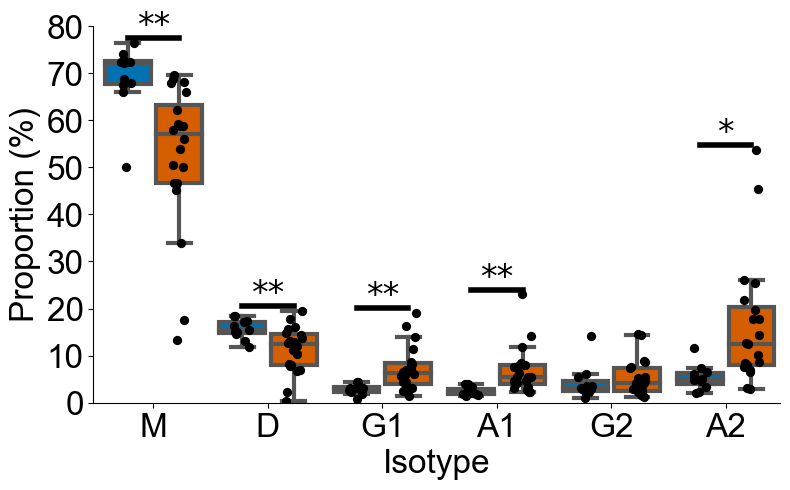

In [14]:
plt.rcParams["figure.figsize"] = (8,5) 
fig,ax = plt.subplots(1,1)

print('SS')
for i in range(len(isotype_list)):
    print(100*sum(isotype_list[i])/len(isotype_list[i]))
print('ASM')
for i in range(len(healthy_isotype_list)):
    print(100*sum(healthy_isotype_list[i])/len(healthy_isotype_list[i]))
    
healthy_isotype_list = healthy_isotype_list[:2]+healthy_isotype_list[3:6]+[healthy_isotype_list[8]]
isotype_list = isotype_list[:2]+isotype_list[3:6]+[isotype_list[8]]
    
bp_pre = plt.boxplot(healthy_isotype_list,sym='',positions = [1,2,3,4,5,6],widths = [0.4]*6,patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

#plt.scatter(sjogren_scatter_x,sjogren_y_val)

#bp_all_sjogren = plt.boxplot([all_sjogren_divergence_list],sym='',positions = [0.0],widths = [0.5],patch_artist=True)
bp_sjogren = plt.boxplot(isotype_list,sym='',positions = [1.45,2.45,3.45,4.45,5.45,6.45],
                         widths = [0.4]*6,patch_artist=True,
                        boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

ticks = ['M','D','G1','A1','G2','A2']
plt.xticks([1.225,2.225,3.225,4.225,5.225,6.225], ticks,font='arial',fontsize = 24)
for i in range(6):
    plot_significance(healthy_isotype_list[i],isotype_list[i],1+i,1.45+i,max(max(healthy_isotype_list[i]),max(isotype_list[i]))+1,0.5,24,4)
    for j in range(len(healthy_isotype_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1+i+0.15*random_x,healthy_isotype_list[i][j],s=32,color = 'k',zorder=10)
    for j in range(len(isotype_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1.45+i+0.15*random_x,isotype_list[i][j],s=32,color = 'k',zorder=10)
plt.yticks(font='arial',fontsize = 24)
plt.xlim(0.7, 6.7)
plt.ylim(0, 80)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Proportion (%)',font='arial',fontsize = 24)
plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
plt.tight_layout()
#plt.savefig(work_dir+'figures/isotype_proportion_box_plot.png')
plt.show()

[0.4775985663082435, 0.12600801207013307, 0.5406504065040652, 0.3638583638583632, 0.24256559766763777, 0.26823529411764746, 0.24689773213521574, 0.20833333333333318, 0.324, 0.3635135135135138]
[0.30294117647058694, 0.37193564862104117, 0.24372955288986234, 0.18225108225108327, 2.0092843019543297e-16, 0.0812500000000005, 0.39602836879432746, 0.21105001309243715, 0.35914615814113465, 0.4278580185999234, 0.3825638727028251, 0.5702804815573763, 0.588858803328491, 0.6092391488210017, 0.10500000000000022, 0.21130952380952428, 0.30285303776683153, 0.4776644736842121, 0.3937078651685386]
[0, 0, 0.0, 0.0, 0.36, 0.4444444444444445, 0, 0.5192307692307693, 0, 0]
[0.686111111111111, 0.5128205128205129, 0.4089635854341735, 0.49999999999999994, 0.1666666666666667, 0.5227272727272728, 0.36263736263736257, 0.5069930069930069, 0.5643939393939398, 0.5000000000000001, 0.6684210526315789, 0, 0.0, 0.0, 0.4700854700854704, 0.40087463556851316, 0.0, 0.633783783783784, 0.3888888888888889]
0.01366575923913877
0

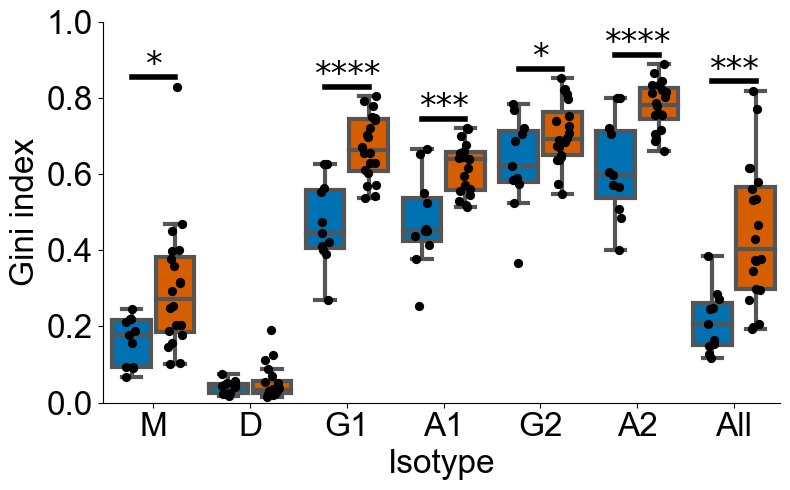

In [10]:
plt.rcParams["figure.figsize"] = (8,5) 
fig,ax = plt.subplots(1,1)
for i in range(10):
    try:
        healthy_gini_list[i].remove(0)
        print(healthy_gini_list[i])
    except ValueError:
        pass
    try:
        gini_list[i].remove(0)
        print(gini_list[i])
    except ValueError:
        pass
    
    
healthy_gini_list = healthy_gini_list[:2]+healthy_gini_list[3:6]+healthy_gini_list[8:]
gini_list = gini_list[:2]+gini_list[3:6]+gini_list[8:]
    
bp_pre = plt.boxplot(healthy_gini_list,sym='',positions = [1,2,3,4,5,6,7],widths = [0.4]*7,patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

#plt.scatter(sjogren_scatter_x,sjogren_y_val)

#bp_all_sjogren = plt.boxplot([all_sjogren_divergence_list],sym='',positions = [0.0],widths = [0.5],patch_artist=True)
bp_sjogren = plt.boxplot(gini_list,sym='',positions = [1.45,2.45,3.45,4.45,5.45,6.45,7.45],
                         widths = [0.4]*7,patch_artist=True,
                        boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

ticks = ['M','D','G1','A1','G2','A2', 'All']
plt.xticks([1.225,2.225,3.225,4.225,5.225,6.225,7.225], ticks,font='arial',fontsize = 24)
for i in range(7):
    plot_significance(healthy_gini_list[i],gini_list[i],1+i,1.45+i,max(max(healthy_gini_list[i]),max(gini_list[i]))+0.025,0.005,24,4)
    for j in range(len(healthy_gini_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1+i+0.15*random_x,healthy_gini_list[i][j],s=32,color = 'k',zorder=10)
    for j in range(len(gini_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1.45+i+0.15*random_x,gini_list[i][j],s=32,color = 'k',zorder=10)
plt.yticks(font='arial',fontsize = 24)
plt.xlim(0.7, 7.7)
plt.ylim(0, 1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Gini index',font='arial',fontsize = 24)
plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
plt.tight_layout()
#plt.savefig(work_dir+'figures/clonality_box_plot.png')
plt.show()

[0, 0, 13.0, 14.0, 16.4, 14.666666666666666, 0, 12.25, 0, 0]
[14.625, 13.333333333333334, 16.941176470588236, 17.0, 7.75, 13.0, 7.25, 7.0, 12.727272727272727, 17.977272727272727, 24.0, 16.142857142857142, 5.5, 11.0, 6.37037037037037, 16.285714285714285, 27.0, 15.4, 11.5]
0.048905210851215034
0.0005393005371327849
0.09889562907356314
0.7785651115527473
0.3589725209437896
0.3298491327087325
0.7018421432380385


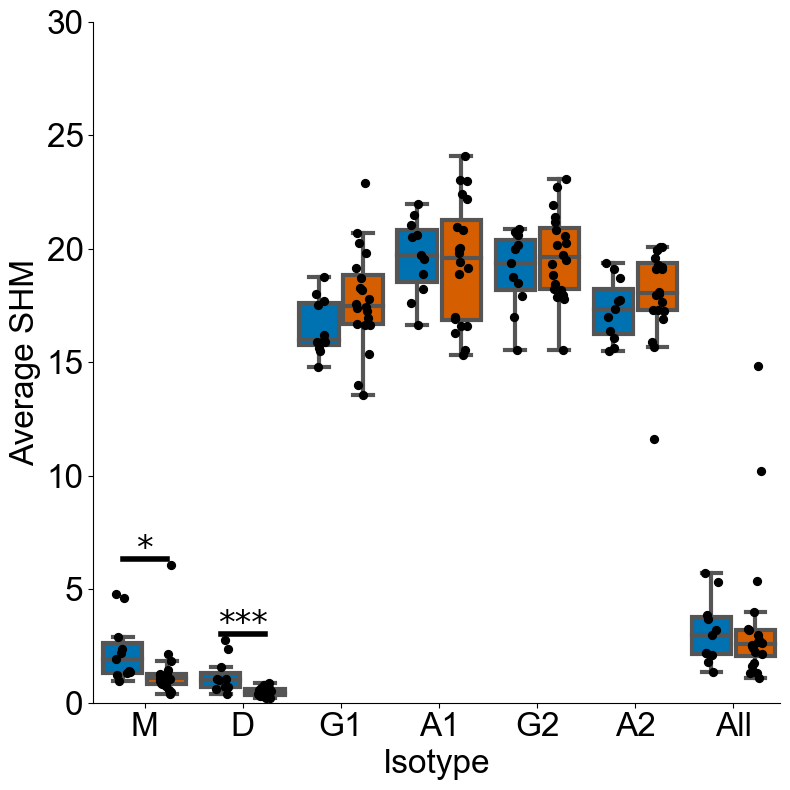

In [11]:
#print(healthy_shm_list)
plt.rcParams["figure.figsize"] = (8,8) 
fig,ax = plt.subplots(1,1)
for i in range(10):
    try:
        healthy_shm_list[i].remove(0)
        print(healthy_shm_list[i])
    except ValueError:
        pass
    try:
        shm_list[i].remove(0)
        print(shm_list[i])
    except ValueError:
        pass
    
healthy_shm_list = healthy_shm_list[:2]+healthy_shm_list[3:6]+healthy_shm_list[8:]
shm_list = shm_list[:2]+shm_list[3:6]+shm_list[8:]
    
bp_pre = plt.boxplot(healthy_shm_list,sym='',positions = [1,2,3,4,5,6,7],widths = [0.4]*7,patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

#plt.scatter(sjogren_scatter_x,sjogren_y_val)
#print(shm_list)
#bp_all_sjogren = plt.boxplot([all_sjogren_divergence_list],sym='',positions = [0.0],widths = [0.5],patch_artist=True)

bp_sjogren = plt.boxplot(shm_list,sym='',positions = [1.45,2.45,3.45,4.45,5.45,6.45,7.45],
                         widths = [0.4]*7,patch_artist=True,
                        boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})

ticks = ['M','D','G1','A1','G2','A2', 'All']
plt.xticks([1.225,2.225,3.225,4.225,5.225,6.225,7.225], ticks,font='arial',fontsize = 24)
for i in range(7):
    plot_significance(healthy_shm_list[i],shm_list[i],1+i,1.45+i,max(max(healthy_shm_list[i]),max(shm_list[i]))+0.25,0.005,24,4)
    for j in range(len(healthy_shm_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1+i+0.15*random_x,healthy_shm_list[i][j],s=32,color = 'k',zorder=10)
    for j in range(len(shm_list[i])):
        random_x = rd.random()-0.5
        plt.scatter(1.45+i+0.15*random_x,shm_list[i][j],s=32,color = 'k',zorder=10)
plt.yticks(font='arial',fontsize = 24)
plt.xlim(0.7, 7.7)
plt.ylim(0, 30)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Average SHM',font='arial',fontsize = 24)
plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
plt.tight_layout()
#plt.savefig(work_dir+'figures/shm_box_plot.png')
plt.show()

2.5176243515490437e-05
0.23049086660680174
8.599883255488495e-06
8.642567527263155e-14


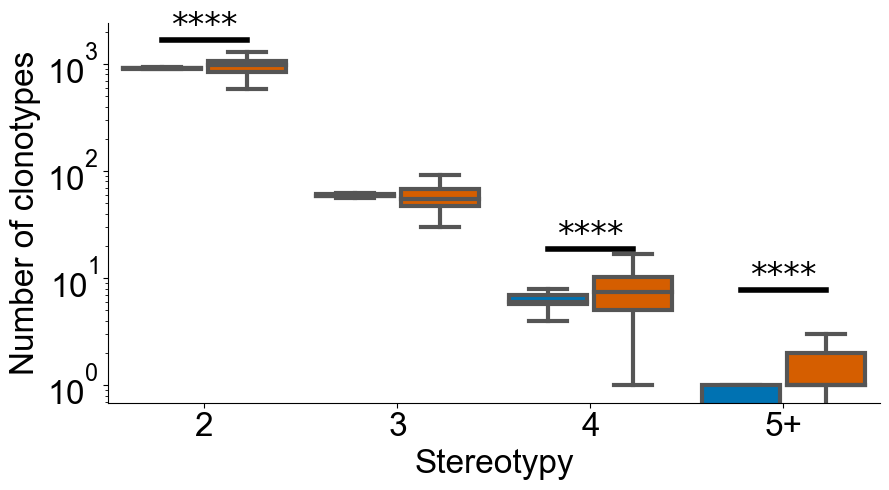

In [12]:
work_dir = 'sjogren/240923_new_analysis/'
isotypes = ['IGHM', 'IGHD','IGHG1','IGHA1','IGHG2','IGHA2']
cmap = plt.cm.Reds 
cmap_list = [cmap(i) for i in range(cmap.N)]


patient_dict = {'C1':0,'C2':1,'C3':2,'C4':3,'C5':4,'C6':5,
                'C7':6,'C8':7,'C9':8,'C10':9,'C11':10}

control_sharing_list = tools.read_csv(work_dir+'250326_ASM_NGS_sampled_nonaivefiltering_unique_sequence_filtering_sharing.csv')
#control_sharing_list = tools.read_csv(work_dir+'250326_ASM_sampled_nonaivefiltering_unique_sequence_filtering_sharing.csv')

hc_convergence_list = tools.extract_column(control_sharing_list,'sharing',int)
hc_v_list = tools.extract_column(control_sharing_list,'v_call',str)
hc_j_list = tools.extract_column(control_sharing_list,'j_call',str)
hc_cdr3_list = tools.extract_column(control_sharing_list,'cdr3_aa',str)
HC_clonotype_dict = {}
for i in range(len(hc_convergence_list)):
    HC_clonotype_dict['_'.join([hc_v_list[i],hc_j_list[i],hc_cdr3_list[i]])] = True

patient_dict = {'S1':0,'S2':1,'S3':2,'S4':3,'S5':4,'S6':5,'S7':6,'S8':7,'S9':8,'S10':9,
                'S11':10,'S12':11,'S13':12,'S14':13,'S15':14,'S16':15,'S17':16,'S18':17,'S19':18,'S20':19}

sharing_list = tools.read_csv(work_dir+'250326_SS_NGS_sampled_nonaivefiltering_unique_sequence_filtering_sharing.csv')
#sharing_list = tools.read_csv(work_dir+'250326_SS_sampled_nonaivefiltering_unique_sequence_filtering_sharing.csv')
sampling = 11
patient_list = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10',
                'S11','S12','S13','S14','S15','S16','S17','S18','S19','S20']

SS_bootstrap = []
HC_bootstrap = []
SS_p = []
for i in range(11):
    SS_bootstrap.append([])
    HC_bootstrap.append([])
    SS_p.append([])
    
samplings = 100
write_list = []
for n in range(samplings):
    sampled_list = rd.sample(patient_list,11)
    write_list.append(sampled_list)
    new_patient_dict = {}
    for s,sampled in enumerate(sampled_list):
        new_patient_dict[sampled] = s

    SS_count = np.zeros(11)

    SS_clonotype_dict = {}
    for line in sharing_list[1:]:
        original = [x.split('_')[0] for x in line[4].split('|')]
        v = line[0]
        j = line[1]
        cdr3 = line[2]
        clonotype = '_'.join([v,j,cdr3])
        count = 0
        for patient in original:
            if patient in sampled_list:
                count += 1
        if count > 1:
            SS_clonotype_dict[clonotype] = True
            if clonotype not in HC_clonotype_dict:
                SS_count[min(count,5)] += 1
        
        
    for i in range(11):
        SS_bootstrap[i].append(SS_count[i])
        
    HC_count = np.zeros(11)
    for line in control_sharing_list[1:]:
        original = [x.split('_')[0] for x in line[4].split('|')]
        v = line[0]
        j = line[1]
        cdr3 = line[2]
        convergence = int(line[3])
        clonotype = '_'.join([v,j,cdr3])
        
        if clonotype not in SS_clonotype_dict:
            HC_count[convergence] += 1
        
    for i in range(11):
        HC_bootstrap[i].append(HC_count[i])
        
#tools.write_csv(write_list,work_dir+'figures/100_samplings_SS.csv')
        
width=0.4
linewidth=3
bias=0.22
plt.rcParams["figure.figsize"] = (9,5) 
fig,ax = plt.subplots(1,1)
for i in range(2,6):
    #color = tuple_to_color(cmap_list[int(len([x for x in SS_p[i] if x <= 0.05])*200/samplings)])
    if i == len(isotypes):
        print(len([x for x in SS_p[i] if x <= 0.05]))
    plt.boxplot([SS_bootstrap[i]],sym='',positions = [i+bias],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    plt.boxplot([HC_bootstrap[i]],sym='',positions = [i-bias],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    """
    sorted_list = sorted(list(SS_bootstrap[i]))
    low = sorted_list[int(samplings/4)]
    med = sorted_list[int(samplings/2)]
    hi = sorted_list[int(3*samplings/4)]
    plt.bar(i,med,color=color,edgecolor='#555555',linewidth=linewidth)
    plt.plot([i-0.2,i+0.2,i,i,i-0.2,i+0.2],[low,low,low,hi,hi,hi],color='k',linewidth=2,zorder=10)
    """
    plot_significance(HC_bootstrap[i],SS_bootstrap[i],i-bias,i+bias,
                      max(max(HC_bootstrap[i]),max(SS_bootstrap[i]))*1.1,
                      max(max(HC_bootstrap[i]),max(SS_bootstrap[i]))*0.1,24,4)
    #plt.scatter(i-bias,np.median(HC_box[i]),s=50,color='#0072B2',zorder=10)
    #plt.plot([i-bias-0.35*width,i-bias+0.35*width],[np.median(HC_box[i]),np.median(HC_box[i])],color='#0072B2',linewidth=2,zorder=10)

plt.yticks(font='arial',fontsize = 24)
plt.xticks([2,3,4,5],['2','3','4','5+'],font='arial',fontsize = 24)
plt.xlim(1.5, 5.5)
plt.yscale('log')
#plt.ylim(-0.5, 20)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Number of clonotypes',font='arial',fontsize = 24)
plt.xlabel('Stereotypy',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
#plt.plot([-0.5, len(isotypes) + 0.5],[0,0],color='k',linewidth=2,zorder=-5)
plt.tight_layout()
#plt.savefig(work_dir+'figures/stereotypy_of_sampled_box_plot.png')
plt.show()

0.0033561192724283974
0.5650939979195644
4.387000229135684e-49
3.392481154504375e-80
5.732972986084232e-60
1.3240731839516352e-87
3.5978945469203144e-59


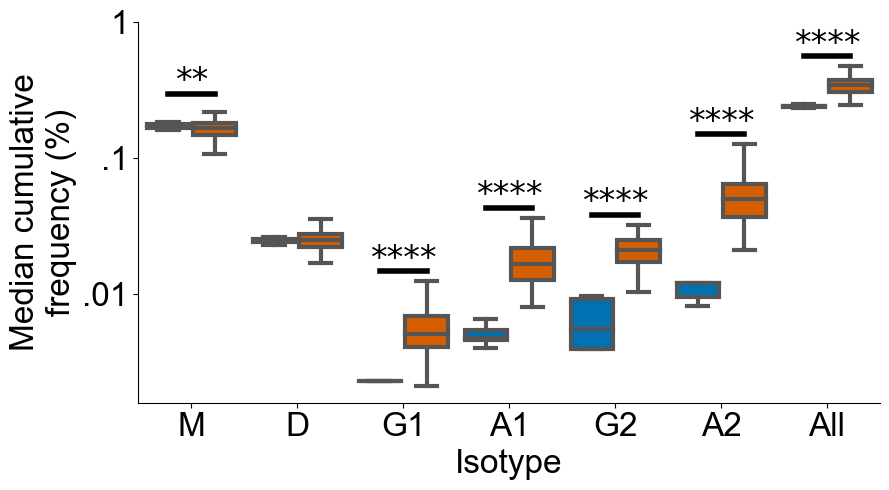

In [22]:
work_dir = 'sjogren/240923_new_analysis/'
isotypes = ['IGHM', 'IGHD','IGHG1','IGHA1','IGHG2','IGHA2']
cmap = plt.cm.Reds 
cmap_list = [cmap(i) for i in range(cmap.N)]


hc_patient_dict = {'C1':0,'C2':1,'C3':2,'C4':3,'C5':4,'C6':5,
                'C7':6,'C8':7,'C9':8,'C10':9,'C11':10}
#hc_patient_dict = {'101-3':0,'105-2':1,'pre-6':2,'pre-9':3,'pre-16':4,'pre-17':5,
#                'pre-18':6,'pre-28':7,'pre-29':8,'pre-30':9,'pre-38':10}
HC_count = np.zeros((len(isotypes)+1,11))
control_sharing_list = tools.read_csv(work_dir+'250326_ASM_NGS_sampled_nonaivefiltering_unique_sequence_filtering_sharing_sequence.csv')
#control_sharing_list = tools.read_csv(work_dir+'250326_ASM_sampled_nonaivefiltering_unique_sequence_filtering_sharing_sequence.csv')

hc_convergence_list = tools.extract_column(control_sharing_list,'sharing',int)
hc_isotype_list = tools.extract_column(control_sharing_list,'c_call',str)
hc_freq_list = tools.extract_column(control_sharing_list,'frequency',float)
hc_name_list = tools.extract_column(control_sharing_list,'patient',str)
hc_v_list = tools.extract_column(control_sharing_list,'v_call',str)
hc_j_list = tools.extract_column(control_sharing_list,'j_call',str)
hc_cdr3_list = tools.extract_column(control_sharing_list,'cdr3_aa',str)
HC_clonotype_dict = {}
for i in range(len(hc_convergence_list)):
    HC_clonotype_dict['_'.join([hc_v_list[i],hc_j_list[i],hc_cdr3_list[i]])] = True

patient_dict = {'S1':0,'S2':1,'S3':2,'S4':3,'S5':4,'S6':5,'S7':6,'S8':7,'S9':8,'S10':9,
                'S11':10,'S12':11,'S13':12,'S14':13,'S15':14,'S16':15,'S17':16,'S18':17,'S19':18,'S20':19}

sharing_list = tools.read_csv(work_dir+'250326_SS_NGS_sampled_nonaivefiltering_unique_sequence_filtering_sharing_sequence.csv')
#sharing_list = tools.read_csv(work_dir+'250326_SS_sampled_nonaivefiltering_unique_sequence_filtering_sharing_sequence.csv')
sampling = 11
patient_list = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10',
                'S11','S12','S13','S14','S15','S16','S17','S18','S19','S20']

SS_bootstrap = []
HC_bootstrap = []
SS_p = []
for i in range(len(isotypes)+1):
    SS_bootstrap.append([])
    HC_bootstrap.append([])
    SS_p.append([])
    
samplings = 100
write_list = []
for n in range(samplings):
    sampled_list = rd.sample(patient_list,11)
    write_list.append(sampled_list)
    new_patient_dict = {}
    for s,sampled in enumerate(sampled_list):
        new_patient_dict[sampled] = s

    sampled_sharing_list = [sharing_list[0]]
    for line in sharing_list[1:]:
        original = [x.split('_')[0] for x in line[2].split('|')]
        count = 0
        for patient in original:
            if patient in sampled_list:
                count += 1
        if count > 1 and line[3].split('_')[0] in sampled_list:
            sampled_sharing_list.append(line)


    SS_count = np.zeros((len(isotypes)+1,11))
    convergence_list = tools.extract_column(sampled_sharing_list,'sharing',int)
    isotype_list = tools.extract_column(sampled_sharing_list,'c_call',str)
    freq_list = tools.extract_column(sampled_sharing_list,'frequency',float)
    name_list = tools.extract_column(sampled_sharing_list,'patient',str)
    v_list = tools.extract_column(sampled_sharing_list,'v_call',str)
    j_list = tools.extract_column(sampled_sharing_list,'j_call',str)
    cdr3_list = tools.extract_column(sampled_sharing_list,'cdr3_aa',str)
    SS_clonotype_dict = {}

    for i in range(len(freq_list)):
        clonotype = '_'.join([v_list[i],j_list[i],cdr3_list[i]])
        SS_clonotype_dict[clonotype] = True
        if clonotype not in HC_clonotype_dict:
            try:
                SS_count[isotypes.index(isotype_list[i]),new_patient_dict[name_list[i].split('_')[0]]] += 100*freq_list[i]
                SS_count[-1,new_patient_dict[name_list[i].split('_')[0]]] += 100*freq_list[i]
            except ValueError:
                continue
            
    SS_box = []
    for i in range(len(isotypes)+1):
        SS_box.append(np.log10(np.array([x for x in SS_count[i,:] if x != 0])))
    
    HC_count = np.zeros((len(isotypes)+1,11))
    for i in range(len(hc_freq_list)):
        clonotype = '_'.join([hc_v_list[i],hc_j_list[i],hc_cdr3_list[i]])
        if clonotype not in SS_clonotype_dict:
            try:
                HC_count[isotypes.index(hc_isotype_list[i]),hc_patient_dict[hc_name_list[i].split('_')[0]]] += 100*hc_freq_list[i]
                HC_count[-1,hc_patient_dict[hc_name_list[i].split('_')[0]]] += 100*hc_freq_list[i]
            except ValueError:
                continue
    HC_box = []
    for i in range(len(isotypes)+1):
        HC_box.append(np.log10(np.array([x for x in HC_count[i,:] if x != 0])))
    
    for i in range(len(isotypes)+1):
        t,p = ttest_ind(HC_box[i],SS_box[i])
        ss = np.median(SS_box[i])
        hc = np.median(HC_box[i])
        SS_p[i].append(p)
        SS_bootstrap[i].append(ss)
        HC_bootstrap[i].append(hc)
        
#tools.write_csv(write_list,work_dir+'figures/100_samplings_SS.csv')
    
        
width=0.4
linewidth=3
bias=0.22
plt.rcParams["figure.figsize"] = (9,5) 
fig,ax = plt.subplots(1,1)
for i in range(len(isotypes)+1):
    plt.boxplot([SS_bootstrap[i]],sym='',positions = [i+bias],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    plt.boxplot([HC_bootstrap[i]],sym='',positions = [i-bias],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    plot_significance(HC_bootstrap[i],SS_bootstrap[i],i-bias,i+bias,
                      max(max(HC_bootstrap[i]),max(SS_bootstrap[i]))+0.07,0.02,24,4)
    """
    sorted_list = sorted(list(SS_bootstrap[i]))
    low = sorted_list[int(samplings/4)]
    med = sorted_list[int(samplings/2)]
    hi = sorted_list[int(3*samplings/4)]
    plt.bar(i,med,color=color,edgecolor='#555555',linewidth=linewidth)
    plt.plot([i-0.2,i+0.2,i,i,i-0.2,i+0.2],[low,low,low,hi,hi,hi],color='k',linewidth=2,zorder=10)
    """
    #plt.scatter(i-bias,np.median(HC_box[i]),s=50,color='#0072B2',zorder=10)
    #plt.plot([i-bias-0.35*width,i-bias+0.35*width],[np.median(HC_box[i]),np.median(HC_box[i])],color='#0072B2',linewidth=2,zorder=10)

plt.yticks([-2,-1,0],['.01','.1','1'],font='arial',fontsize = 24)
plt.xticks(range(len(isotypes)+1),['M','D','G1','A1','G2','A2','All'],font='arial',fontsize = 24)
plt.xlim(-0.5, len(isotypes) + 0.5)
#plt.ylim(0, 4)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Median cumulative\nfrequency (%)',font='arial',fontsize = 24)
plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
#plt.plot([-0.5, len(isotypes) + 0.5],[0,0],color='k',linewidth=2,zorder=-5)
plt.tight_layout()
#plt.savefig(work_dir+'figures/repertoire_overlap_box_plot.png')
plt.show()


IGHV4-59 IGHJ2 ARDRYCSGGSCFDWYFDL 13
IGHV4-59 IGHJ2 ARDTYCRGGSCFDWYFDL 6
IGHV3-30 IGHJ3 ARGGNDYVWGSYRLDAFDI 6
IGHV1-18 IGHJ4 ARDPNYGSGSSLFDY 5
IGHV1-18 IGHJ4 ARDSGVGYFDS 5
IGHV3-11 IGHJ5 ARDGGRWFDP 5
IGHV3-74 IGHJ4 ARSVEWGCDY 4
IGHV3-23 IGHJ4 AKDPIVVVTAILDY 4
IGHV3-23 IGHJ4 AKDRGITIPRGIDY 4
IGHV3-21 IGHJ4 ARDYYDILTGYQYYFDY 4
IGHV3-30 IGHJ4 ARGYASGSFDY 4
IGHV7-4-1 IGHJ4 AREDSSGYYSFDY 4
IGHV7-4-1 IGHJ4 AREDSSSWYYFDY 4
IGHV4-59 IGHJ2 ARDRYCGGGSCYDWYFDL 4
IGHV4-59 IGHJ2 ARDTYCSGGSCYDWYFDL 4
IGHV4-59 IGHJ2 ARDTYCSGGSCFDWYFDV 4
IGHV1-18 IGHJ4 ARDDGRHYLDY 4
IGHV1-18 IGHJ4 ARDSGTYYFDS 4
IGHV4-59 IGHJ6 ARGAAGIYYYYYYMDV 4
IGHV3-7 IGHJ4 ARAERDGYNGF 3
IGHV3-7 IGHJ4 VRDSGYDKGDY 3
IGHV3-7 IGHJ4 ARGRRDGYHDN 3
IGHV3-7 IGHJ4 ARGRRDGYKDY 3
IGHV3-7 IGHJ4 ANAPTSTDSDY 3
IGHV3-7 IGHJ4 GRFTRRYPDDY 3
IGHV3-74 IGHJ4 TRDIGGLGAY 3
IGHV3-74 IGHJ4 TRDIGGQGAF 3
IGHV3-74 IGHJ4 VREFGGTRDF 3
IGHV3-74 IGHJ4 SRDLSGYYDQ 3
IGHV3-74 IGHJ4 VRSVEWGLDY 3
IGHV3-15 IGHJ4 TRGAPPSSFFDF 3
IGHV3-30 IGHJ4 ARDFVTGAPDYFDY 3
IGHV3-7 IG

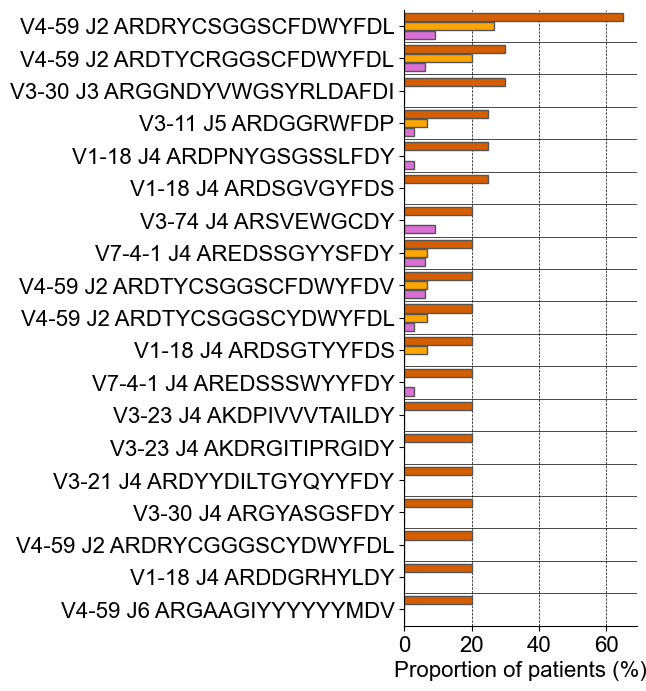

S5
S13
S14
S2
S12
S11
S6
S4
S7
S1
S10
S3
S9
RA11
RA13
RA4
RA10
DSN_4
NMO_4
MOG_3
S5
S12
S11
S6
S10
S9
RA4
RA10
RA11
NMO_4
MOG_3
S13
S2
S8
S20
S15
S9
S13
S2
S20
S10
S3
MOG_7
S2
S6
S18
S20
S3
S19
S13
S20
S10
S3
RA12
DSN_2
S14
S6
S20
S3
NMO_2
NMO_5
NMO_9
S13
S7
S18
S16
S13
S2
S7
S15
S5
S2
S12
S4
S5
S4
S1
S10
S13
S2
S20
S10
RA2
MOG_11
DSN_4
S13
S20
S10
S3
DSN_2
S5
S2
S6
S10
S12
S6
S10
S9
RA10
NMO_4
S12
S11
S10
S9
RA10
DSN_4
NMO_4
S2
S12
S18
S15
S19
S2
S18
S20
RA14
S17
S11
S18
S20
[[10. 10.  9.  8.  6.  6.  6.  5.  5.  5.  4.  3.  3.  3.  2.  2.  2.  1.
   1.  1.]]


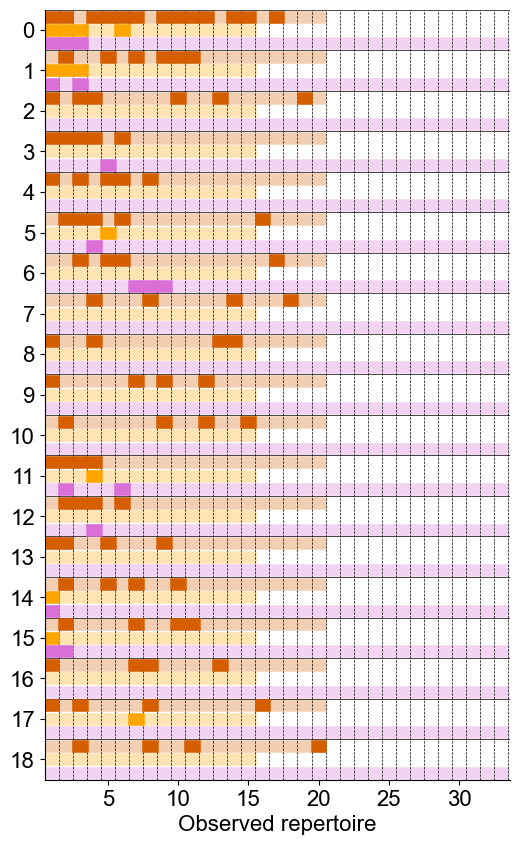

4.0
2.0
2.0
1.0
1.0
1.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
['S2', 'S10', 'S20', 'S13', 'S6', 'S3', 'S12', 'S18', 'S5', 'S9', 'S11', 'S4', 'S15', 'S7', 'S1', 'S19', 'S14', 'S16', 'S8', 'S17']


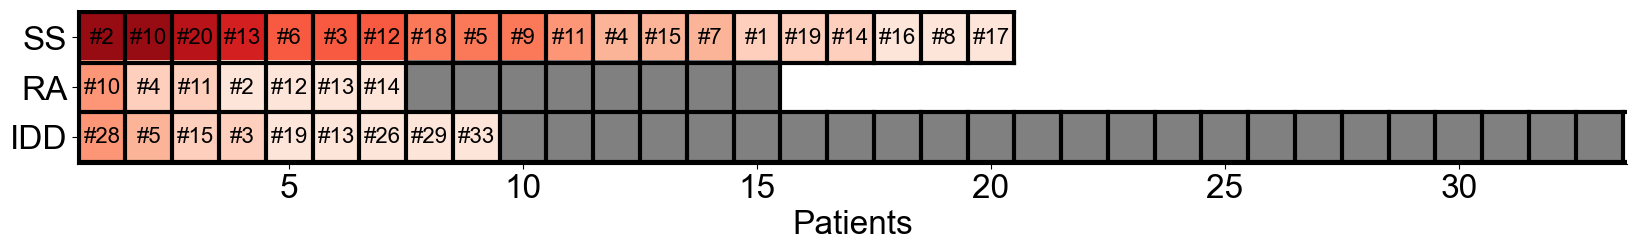

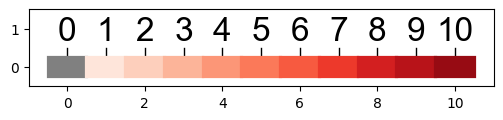

In [21]:
workdir = 'sjogren/240923_new_analysis/'
clonotype_ref_file = tools.read_csv(workdir+'250520_SS_extended_sharing_all_control_no_filtered.csv')
clonotype_ref_dict = {}
for line in clonotype_ref_file[1:]:
    #clonotype_ref_dict['_'.join(line[:3])] = len(line[5].split('|')[0].split(';'))
    clonotype_ref_dict['_'.join(line[:3])] = len(line[1].split('|')[0].split(';'))

extended_clonotype_ref_file = tools.read_csv(workdir+'250520_SS_extended_sharing_global_analysis_noHC.csv')
extended_clonotype_ref_dict = {}
for line in extended_clonotype_ref_file[1:]:
    clonotype = line[0]
    v = clonotype.split('_')[0]
    j = clonotype.split('_')[1]
    cdr3 = clonotype.split('_')[2]
    in_cluster = False
    for query in extended_clonotype_ref_dict:
        query_v = query.split('_')[0]
        query_j = query.split('_')[1]
        query_cdr3 = query.split('_')[2]
        if query_v == v and query_j == j and len(cdr3) == len(query_cdr3):
            if hamming(query_cdr3,cdr3) <= 0.1* len(cdr3):
                extended_clonotype_ref_dict[query][1].append(clonotype)
                if extended_clonotype_ref_dict[query][0] < int(line[8]):
                    extended_clonotype_ref_dict[query][0] = int(line[8])
                for patient in line[21].split('|'):
                    if 'CIDP' not in patient and patient.replace('.tsv','') not in extended_clonotype_ref_dict[query][5]:
                        extended_clonotype_ref_dict[query][5].append(patient.replace('.tsv',''))
                for patient in line[22].split('|'):
                    if patient.replace('_RF+.tsv','').replace('_RF-.tsv','') not in extended_clonotype_ref_dict[query][6]:
                        extended_clonotype_ref_dict[query][6].append(patient.replace('_RF+.tsv','').replace('_RF-.tsv',''))
                in_cluster = True
    if in_cluster == False:
        extended_clonotype_ref_dict[clonotype] = [int(line[8]),
                                                  [],
                                                  len([x for x in line[21].split('|') if 'CIDP' not in x]),
                                                  len(line[22].split('|')),
                                                  [x.replace('_add_d_gene.tsv','') for x in line[23].split('|')],
                                                  [x.replace('.tsv','') for x in line[21].split('|') if 'CIDP' not in x],
                                                  [x.replace('_RF+.tsv','').replace('_RF-.tsv','') for x in line[22].split('|')]]

bar_plot = []
sorted_extended_clonotype_ref_dict = dict(sorted(extended_clonotype_ref_dict.items(), key=lambda x:x[1][0],reverse=True))
for key in sorted_extended_clonotype_ref_dict:
    if sorted_extended_clonotype_ref_dict[key][0] >= 2:
        print(key.replace('_',' '),sorted_extended_clonotype_ref_dict[key][0])
              #len([x for x in sorted_extended_clonotype_ref_dict[key][6] if x != '']),
              #len([x for x in sorted_extended_clonotype_ref_dict[key][5] if x != '']))
        bar_plot.append([key,sorted_extended_clonotype_ref_dict[key][0],
                         len([x for x in sorted_extended_clonotype_ref_dict[key][6] if x != '']),
                         len([x for x in sorted_extended_clonotype_ref_dict[key][5] if x != '']),
                         sorted_extended_clonotype_ref_dict[key][4],
                         [x for x in sorted_extended_clonotype_ref_dict[key][6] if x != ''],
                         [x for x in sorted_extended_clonotype_ref_dict[key][5] if x != ''],
                        ])
        
label_list = []
plt.rcParams["figure.figsize"] = (3,8)
fig, ax = plt.subplots()
bias=0.28
width=0.25
color = ['#D55E00','orange','orchid','lime','crimson','gray']
new_bar_plot = [
    bar_plot[0],bar_plot[1],bar_plot[2],bar_plot[5],bar_plot[3],bar_plot[4],
    bar_plot[6],bar_plot[11],bar_plot[15],bar_plot[14],bar_plot[17],bar_plot[12],
    bar_plot[7],bar_plot[8],bar_plot[9],bar_plot[10],bar_plot[13],bar_plot[16],bar_plot[18]
]

for k,line in enumerate(new_bar_plot):
    #if len(mapping_dict[key]) != len(mapping_mismatch10_dict[key]):
    label_list.append(line[0].replace('_',' ').replace('IGH',''))
    
    bar = [100*line[1]/20,100*line[2]/15,100*line[3]/33]

    plt.barh(k-bias,bar[0],color=color[0], edgecolor='#555555',linewidth=1, height=width)
    #if 0 < bar[0]:
    #    plt.text(bar[0]+0.3,k-bias+0.12,"%.1f" % (bar[0])+'%',
    #             ha='left',va='center',color=color[0],font='arial',fontsize = 11)
            
    plt.barh(k,bar[1],color=color[1], edgecolor='#555555',linewidth=1, height=width)
    #if 0 < bar[1]:
    #    plt.text(bar[1]+0.3,k+0.12,"%.1f" % (bar[1])+'%',
    #             ha='left',va='center',color=color[1],font='arial',fontsize = 11)
        
    plt.barh(k+bias,bar[2],color=color[2], edgecolor='#555555',linewidth=1, height=width)
    #if 0 < bar[2]:
    #    plt.text(bar[2]+0.3,k+bias+0.12,"%.1f" % (bar[2])+'%',
    #             ha='left',va='center',color=color[2],font='arial',fontsize = 11)


    
plt.xticks([0,20,40,60],['0','20','40','60'],font='arial',fontsize = 16)
plt.yticks(range(len(label_list)),label_list,font='arial',fontsize = 16)
plt.xlabel('Proportion of patients (%)',font='arial',fontsize = 16)
plt.ylim(len(label_list)-0.5,-0.5)
plt.xlim(0,69)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for i in range(1,4):
    plt.plot([i*20,i*20],[len(label_list)-0.5,-0.5],color='k',linewidth=0.5,linestyle='--',zorder=-20)
for i in range(1,22):
    plt.plot([0,69],[i-0.5,i-0.5],color='k',linewidth=0.5,zorder=-20)

plt.show()

label_list = []
plt.rcParams["figure.figsize"] = (6,10)
fig, ax = plt.subplots()
bias=0.33
width=0.25
color = ['#D55E00','orange','orchid','lime','crimson','gray']

patient_dict = {'S1':15/20,'S2':1/20,'S3':6/20,'S4':12/20,'S5':9/20,
                'S6':5/20,'S7':14/20,'S8':19/20,'S9':10/20,'S10':2/20,
                'S11':11/20,'S12':7/20,'S13':4/20,'S14':17/20,'S15':13/20,
                'S16':18/20,'S17':20/20,'S18':8/20,'S19':16/20,'S20':3/20,
                'RA1':8/15,'RA2':4/15,'RA3':9/15,'RA4':2/15,'RA5':10/15,
                'RA6':11/15,'RA7':12/15,'RA8':14/15,'RA9':13/15,'RA10':1/15,
                'RA11':3/15,'RA12':5/15,'RA13':6/15,'RA14':7/15,'RA15':15/15,
                'DSN_1':15/33,'DSN_10':29/33,'DSN_2':4/33,'DSN_3':19/33,'DSN_4':2/33,
                'DSN_5':13/33,'DSN_6':26/33,'DSN_7':28/33,'DSN_8':33/33,'DSN_9':10/33,
                'MOG_1':11/33,'MOG_10':12/33,'MOG_11':6/33,'MOG_2':14/33,'MOG_3':3/33,
                'MOG_4':16/33,'MOG_5':17/33,'MOG_6':18/33,'MOG_7':5/33,'MOG_8':20/33,
                'MOG_9':21/33,'NMO_1':22/33,'NMO_10':23/33,'NMO_11':24/33,'NMO_12':25/33,
                'NMO_2':7/33,'NMO_3':27/33,'NMO_4':1/33,'NMO_5':8/33,'NMO_6':30/33,
                'NMO_7':31/33,'NMO_8':32/33,'NMO_9':9/33}

span = 0.13
linewidth=9
alpha = 0.3

ss_result = np.zeros((1,20))
ra_result = np.zeros((1,15))
idd_result = np.zeros((1,33))
ss_label_list = ['']*20
ra_label_list = ['']*15
idd_label_list = ['']*33
idd_dict = {'DSN_1':'I1','DSN_10':'I2','DSN_2':'I3','DSN_3':'I4','DSN_4':'I5',
                'DSN_5':'I6','DSN_6':'I7','DSN_7':'I8','DSN_8':'I9','DSN_9':'I10',
                'MOG_1':'I11','MOG_10':'I12','MOG_11':'I13','MOG_2':'I14','MOG_3':'I15',
                'MOG_4':'I16','MOG_5':'I17','MOG_6':'I18','MOG_7':'I19','MOG_8':'I20',
                'MOG_9':'I21','NMO_1':'I22','NMO_10':'I23','NMO_11':'I24','NMO_12':'I25',
                'NMO_2':'I26','NMO_3':'I27','NMO_4':'I28','NMO_5':'I29','NMO_6':'I30',
                'NMO_7':'I31','NMO_8':'I32','NMO_9':'I33'}
for k,line in enumerate(bar_plot[:19]):
    #if len(mapping_dict[key]) != len(mapping_mismatch10_dict[key]):
    label_list.append(line[0].replace('_',' ').replace('IGH',''))
    #print(line)
    patients = line[4]+line[5]+line[6]
    #print(patients)
    for file in patients:
        if file != '':
            print(file)
            if file[0] == 'S' and len(file) < 4:
                index = 20*patient_dict[file]
                ss_result[0,int(index)-1] += 1
                ss_label_list[int(index)-1] = file
                plt.plot([index-span,index+span],[k-bias,k-bias],linewidth=linewidth,color=color[0])
            elif 'RA' in file:
                index = 15*patient_dict[file]
                plt.plot([index-span,index+span],[k,k],linewidth=linewidth,color=color[1])
                ra_result[0,int(index)-1] += 1
                ra_label_list[int(index)-1] = file.replace('A','')
            elif 'NMO' in file or 'MOG' in file or 'DSN' in file:
                index = 33*patient_dict[file]
                plt.plot([index-span,index+span],[k+bias,k+bias],linewidth=linewidth,color=color[2])
                idd_result[0,int(index)-1] += 1
                idd_label_list[int(index)-1] = idd_dict[file]
print(ss_result)
plt.xticks(font='arial',fontsize = 16)
plt.yticks(range(22), range(22), font='arial',fontsize = 16)
plt.xlabel('Observed repertoire',font='arial',fontsize = 16)
plt.ylim(len(label_list)-0.5,-0.5)
plt.xlim(0.5,33.6)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for i in range(1,35):
    plt.plot([i-0.5,i-0.5],[len(label_list)-0.5,-0.5],color='k',linewidth=0.5,linestyle='--',zorder=-20)
for i in range(0,22):
    plt.plot([0.5,34.5],[i-0.5,i-0.5],color='k',linewidth=0.5,zorder=-20)
    plt.plot([0.5,20+span],[i-bias,i-bias],linewidth=linewidth,color=color[0],alpha=alpha,zorder=-40)
    plt.plot([0.5,15+span],[i,i],linewidth=linewidth,color=color[1],alpha=alpha,zorder=-40)
    plt.plot([0.5,33+span],[i+bias,i+bias],linewidth=linewidth,color=color[2],alpha=alpha,zorder=-40)
plt.show()

cmap = plt.cm.Reds  # define the colormap
# extract all colors from the .jet map
cmap_list = [cmap(i) for i in range(cmap.N)]

plt.rcParams["figure.figsize"] = (20,2)
fig, ax = plt.subplots()

span = 0.15
linewidth=36
width=0.333
for i in range(20):
    color = tuple_to_color(cmap_list[int(23*ss_result[0,i])])
    if ss_result[0,i] == 0:
        color='gray'
    plt.plot([i,i],[-bias-0.5*width+span,-bias+0.5*width-span],color=color,linewidth=linewidth)
for i in range(15):
    print(ra_result[0,i])
    color = tuple_to_color(cmap_list[int(23*ra_result[0,i])])
    if ra_result[0,i] == 0:
        color='gray'
    plt.plot([i,i],[-0.5*width+span,0.5*width-span],color=color,linewidth=linewidth)
for i in range(33):
    color = tuple_to_color(cmap_list[int(23*idd_result[0,i])])
    if idd_result[0,i] == 0:
        color='gray'
    plt.plot([i,i],[bias-0.5*width+span,bias+0.5*width-span],color=color,linewidth=linewidth)

    
linewidth = 3
for i in range(21):
    plt.plot([i-0.5,i-0.5],[0-bias-0.5*width,0-bias+0.5*width],color='k',linewidth=linewidth,zorder=20)
for i in range(16):
    plt.plot([i-0.5,i-0.5],[0-0.5*width,0+0.5*width],color='k',linewidth=linewidth,zorder=20)
for i in range(35):
    plt.plot([i-0.5,i-0.5],[0+bias-0.5*width,0+bias+0.5*width],color='k',linewidth=linewidth,zorder=20)
    
plt.plot([-0.5,19.5],[-bias-0.5*width,-bias-0.5*width],color='k',linewidth=linewidth,zorder=20)
plt.plot([-0.5,19.5],[-bias+0.5*width,-bias+0.5*width],color='k',linewidth=linewidth,zorder=20)
plt.plot([-0.5,33.5],[0.5*width,0.5*width],color='k',linewidth=linewidth,zorder=20)
plt.plot([-0.5,33.5],[bias+0.5*width,bias+0.5*width],color='k',linewidth=linewidth,zorder=20)

print(ss_label_list)
for l,label in enumerate(ss_label_list):
    if len(label) > 1:
        plt.text(l,-bias,'#'+label[1:],color='k',font='arial',fontsize = 16,ha='center',va='center',zorder=100)
for l,label in enumerate(ra_label_list):
    if len(label) > 1:
        plt.text(l,0,'#'+label[1:],color='k',font='arial',fontsize = 16,ha='center',va='center',zorder=100)
for l,label in enumerate(idd_label_list):
    if len(label) > 1:
        plt.text(l,bias,'#'+label[1:],color='k',font='arial',fontsize = 16,ha='center',va='center',zorder=100)

    
plt.xlim(-0.53,32.6)
plt.ylim(bias+0.53*width,-bias-0.55*width)
plt.xlabel('Patients',font='arial',fontsize = 24)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks([4,9,14,19,24,29],['5','10','15','20','25','30'],font='arial',fontsize = 24)
plt.yticks([-bias,0,bias],['SS','RA','IDD'],font='arial',fontsize = 24)
plt.show()

plt.rcParams["figure.figsize"] = (6,1)
fig, ax = plt.subplots()
span=0.25
for i in range(11):
    if i == 0 :
        color = 'gray'
    else:
        color = tuple_to_color(cmap_list[int(23*i)])
    plt.plot([i-0.5+span,i+0.5-span],[0,0],color=color,linewidth=16,zorder=20)
    plt.plot([i,i],[0,0.5],color='k',linewidth=1,zorder=0)
    plt.text(i,0.5,str(i),font='arial',fontsize = 24,ha='center',va='bottom')
plt.xlim(-1,11)
plt.ylim(-0.5,1.5)
plt.show()

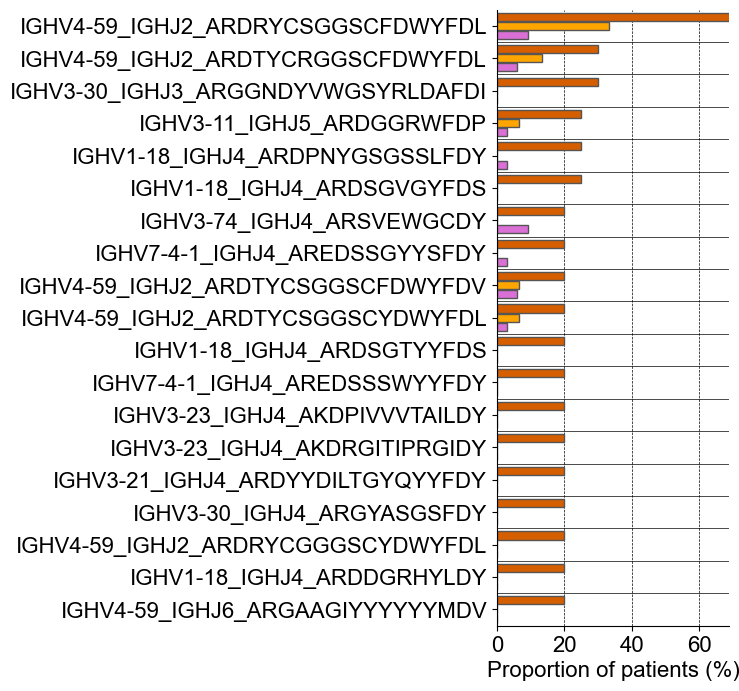

In [3]:
file = 'sjogren/240923_new_analysis/260317_ss_stereotypic_extended_clonotypes_mismatch10.csv'
label_list = [
'IGHV4-59_IGHJ2_ARDRYCSGGSCFDWYFDL',
'IGHV4-59_IGHJ2_ARDTYCRGGSCFDWYFDL',
'IGHV3-30_IGHJ3_ARGGNDYVWGSYRLDAFDI',
'IGHV3-11_IGHJ5_ARDGGRWFDP',
'IGHV1-18_IGHJ4_ARDPNYGSGSSLFDY',
'IGHV1-18_IGHJ4_ARDSGVGYFDS',
'IGHV3-74_IGHJ4_ARSVEWGCDY',
'IGHV7-4-1_IGHJ4_AREDSSGYYSFDY',
'IGHV4-59_IGHJ2_ARDTYCSGGSCFDWYFDV',
'IGHV4-59_IGHJ2_ARDTYCSGGSCYDWYFDL',
'IGHV1-18_IGHJ4_ARDSGTYYFDS',
'IGHV7-4-1_IGHJ4_AREDSSSWYYFDY',
'IGHV3-23_IGHJ4_AKDPIVVVTAILDY',
'IGHV3-23_IGHJ4_AKDRGITIPRGIDY',
'IGHV3-21_IGHJ4_ARDYYDILTGYQYYFDY',
'IGHV3-30_IGHJ4_ARGYASGSFDY',
'IGHV4-59_IGHJ2_ARDRYCGGGSCYDWYFDL',
'IGHV1-18_IGHJ4_ARDDGRHYLDY',
'IGHV4-59_IGHJ6_ARGAAGIYYYYYYMDV'
]

color = ['#D55E00','orange','orchid']
temp_list = tools.read_csv(file)
bar_plot = []
for e,esbc in enumerate(label_list):
    bar_plot.append([[],[],[]])
    for line in temp_list:
        if line[0] == esbc:
            shm = int(line[8])
            if line[1] == 'PBMC/SS':
                bar_plot[-1][0].append(line[2])
            elif line[1] == 'PBMC/RA':
                bar_plot[-1][1].append(line[2])
            elif (line[1] == 'PBMC/NMO' or line[1] == 'PBMC/MOG') and 'CIDP'not in line[2]:
                bar_plot[-1][2].append(line[2])

plt.rcParams["figure.figsize"] = (3,8)
fig, ax = plt.subplots()
bias=0.28
width=0.25
new_bar_plot = []
for line in bar_plot:
    temp = [len(tools.unique(line[0])),len(tools.unique(line[1])),len(tools.unique(line[2]))]
    new_bar_plot.append(temp)

for k,line in enumerate(new_bar_plot):
    bar = [100*line[0]/20,100*line[1]/15,100*line[2]/33]

    plt.barh(k-bias,bar[0],color=color[0], edgecolor='#555555',linewidth=1, height=width)    
    plt.barh(k,bar[1],color=color[1], edgecolor='#555555',linewidth=1, height=width) 
    plt.barh(k+bias,bar[2],color=color[2], edgecolor='#555555',linewidth=1, height=width)
    
plt.xticks([0,20,40,60],['0','20','40','60'],font='arial',fontsize = 16)
plt.yticks(range(len(label_list)),label_list,font='arial',fontsize = 16)
plt.xlabel('Proportion of patients (%)',font='arial',fontsize = 16)
plt.ylim(len(label_list)-0.5,-0.5)
plt.xlim(0,69)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for i in range(1,4):
    plt.plot([i*20,i*20],[len(label_list)-0.5,-0.5],color='k',linewidth=0.5,linestyle='--',zorder=-20)
for i in range(1,22):
    plt.plot([0,69],[i-0.5,i-0.5],color='k',linewidth=0.5,zorder=-20)

plt.show()

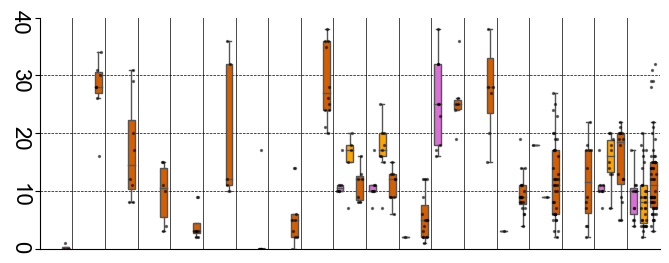

In [4]:
file = 'sjogren/240923_new_analysis/260317_ss_stereotypic_extended_clonotypes_mismatch10.csv'
label_list = [
'IGHV4-59_IGHJ2_ARDRYCSGGSCFDWYFDL',
'IGHV4-59_IGHJ2_ARDTYCRGGSCFDWYFDL',
'IGHV3-30_IGHJ3_ARGGNDYVWGSYRLDAFDI',
'IGHV3-11_IGHJ5_ARDGGRWFDP',
'IGHV1-18_IGHJ4_ARDPNYGSGSSLFDY',
'IGHV1-18_IGHJ4_ARDSGVGYFDS',
'IGHV3-74_IGHJ4_ARSVEWGCDY',
'IGHV7-4-1_IGHJ4_AREDSSGYYSFDY',
'IGHV4-59_IGHJ2_ARDTYCSGGSCFDWYFDV',
'IGHV4-59_IGHJ2_ARDTYCSGGSCYDWYFDL',
'IGHV1-18_IGHJ4_ARDSGTYYFDS',
'IGHV7-4-1_IGHJ4_AREDSSSWYYFDY',
'IGHV3-23_IGHJ4_AKDPIVVVTAILDY',
'IGHV3-23_IGHJ4_AKDRGITIPRGIDY',
'IGHV3-21_IGHJ4_ARDYYDILTGYQYYFDY',
'IGHV3-30_IGHJ4_ARGYASGSFDY',
'IGHV4-59_IGHJ2_ARDRYCGGGSCYDWYFDL',
'IGHV1-18_IGHJ4_ARDDGRHYLDY',
'IGHV4-59_IGHJ6_ARGAAGIYYYYYYMDV'
]
plt.rcParams["figure.figsize"] = (8,3)
fig, ax = plt.subplots()
bias=0.3
width=0.7*bias
linewidth = 1
color = ['#D55E00','orange','orchid']
temp_list = tools.read_csv(file)
for e,esbc in enumerate(label_list):
    box = [[],[],[]]
    for line in temp_list:
        if line[0] == esbc:
            shm = int(line[8])
            if line[1] == 'PBMC/SS':
                box[0].append(shm)
            elif line[1] == 'PBMC/RA':
                box[1].append(shm)
            elif (line[1] == 'PBMC/NMO' or line[1] == 'PBMC/MOG') and 'CIDP'not in line[2]:
                box[2].append(shm)
    for i in range(3):
        plt.boxplot([box[i]],sym='',positions = [18-e-(i-1)*bias],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':color[i],'edgecolor':'#555555','linewidth':linewidth},
                    whiskerprops = {'color':'#555555','linewidth':linewidth},
                    capprops = {'color':'#555555','linewidth':linewidth},
                    medianprops = {'color':'#555555','linewidth':linewidth})
        plt.scatter([18-e-(i-1)*bias+0.8*width*(rd.random()-0.5) for x in box[i]],
                    box[i],color='k',alpha=0.5,s=2,zorder=20+e)

    
plt.xticks([])
plt.yticks([0,10,20,30,40],['0','10','20','30','40'],font='arial',fontsize = 16,rotation=-90)
#plt.ylabel('SHM (nt)',font='arial',fontsize = 16,rotation=-90)
plt.ylim(0,40)
plt.xlim(-0.5,18.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for i in range(18):
    plt.plot([i+0.5,i+0.5],[0,60],color='k',linewidth=0.5,zorder=-20)
for i in range(1,4):
    plt.plot([-0.5,18.5],[10*i,10*i],color='k',linewidth=0.5,linestyle='--',zorder=-20)

plt.show()

[44.0, 40.0, 7.0]
[49.0, 20.0, 7.0]
[7.0, 0, 0]
[43.0, 1.0, 1.0]
[15.0, 0, 1.0]
[10.0, 0, 0]
[9.0, 0, 52.0]
[37.0, 0, 1.0]
[9.0, 12.0, 7.0]
[10.0, 6.0, 7.0]
[53.99999999999999, 0, 0]
[11.0, 0, 0]
[18.0, 0, 0]
[25.0, 0, 0]
[34.00000000000001, 0, 0]
[3.0, 0, 0]
[7.0, 0, 0]
[18.0, 0, 0]
[16.0, 0, 0]


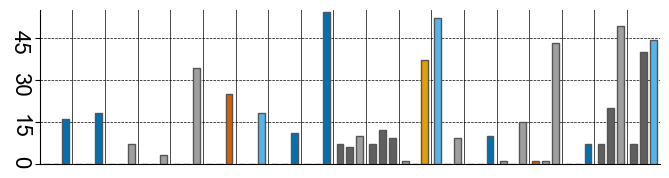

In [13]:
med_dict = {
'S1':2.5162613389026585e-06,'S2':1.3645487505509365e-06,'S3':1.5556284972473153e-06,'S4':1.0573540560630267e-06,
'S5':1.2947279970687358e-06,'S6':3.347000251025019e-06,'S7':2.4956886977745943e-06,'S8':7.809327460719083e-06,
'S9':1.4420400829461456e-06,'S10':1.0918508619070705e-06,'S11':1.5542068493895852e-06,'S12':1.1457811764193652e-06,
'S13':1.00290038792187e-06,'S14':2.972907890394832e-06,'S15':1.4570951060546673e-06,'S16':1.8389350359419854e-06,
'S17':1.2727342149138996e-06,'S18':1.3843838730353862e-06,'S19':1.674607095310263e-06,'S20':3.6553314837356027e-06,
'DSN_1':3.007600205719854e-06,'DSN_10':5.3794965867094155e-06,'DSN_2':2.5512156542592544e-06,'DSN_3':6.02990834539315e-06,
'DSN_4':1.1973839555339493e-06,'DSN_5':6.380969396870773e-06,'DSN_6':4.471711950203015e-06,'DSN_7':6.110265857667467e-06,
'DSN_8':1.2748500138958651e-06,'DSN_9':1.9573723450690853e-06,'NMO_1':4.3910839917763777e-07,'NMO_10':1.9391231672862163e-06,
'NMO_11':4.4489111512402895e-07,'NMO_12':1.209896469159134e-06,'NMO_2':1.6894431764234826e-06,'NMO_3':1.1411096149896159e-05,
'NMO_4':8.20438770654546e-06,'NMO_5':3.5303379592528394e-06,'NMO_6':4.122198450877822e-06,'NMO_7':2.847899389410371e-06,
'NMO_8':1.0043286565095562e-05,'NMO_9':3.320902089843685e-06,'MOG_1':1.7110484106926837e-06,'MOG_10':4.995678737891724e-06,
'MOG_11':1.3264604993327904e-06,'MOG_2':1.2951908269404872e-06,'MOG_3':6.058146086134721e-06,'MOG_4':5.018392408175965e-06,
'MOG_5':2.7534555867613855e-05,'MOG_6':4.888469566832712e-06,'MOG_7':5.296357694813277e-06,'MOG_8':2.830199359242865e-06,
'MOG_9':3.551994089481835e-06,
'RA10_RF+':5.474352657798215e-06,'RA11_RF+':3.000678153262637e-06,'RA12_RF+':2.3874667545254432e-06,'RA13_RF+':2.783019130473503e-06,
'RA14_RF+':2.9152564113776626e-06,'RA15_RF+':3.941694455612579e-06,'RA1_RF-':2.419163646744048e-06,'RA2_RF-':2.3383553411543523e-06,
'RA3_RF+':4.5152638494430425e-06,'RA4_RF-':4.4797046978663166e-06,'RA5_RF+':4.831431359854671e-06,'RA6_RF-':1.8401430895266416e-06,
'RA7_RF+':4.155205225586092e-06,'RA8_RF-':5.249095843241002e-06,'RA9_RF+':2.2466962331890952e-06}
plt.rcParams["figure.figsize"] = (8,2)
fig, ax = plt.subplots()
bias=0.3
width=0.7*bias
linewidth = 1
color = ['#D55E00','orange','orchid']
isotypes = ['IGHM', 'IGHD','IGHG3','IGHG1','IGHA1','IGHG2','IGHG4','IGHGP','IGHA2']
color_dict = {'IGHM':'#9F9F9F','IGHD':'#5F5F5F', 'IGHG3':'#F0E442', 'IGHG1':'#D55E00',
              'IGHA1':'#0072B2','IGHG2':'#E69F00','IGHG4':'#CC79A7','IGHGP':'#E69F00','IGHA2':'#56B4E9'}
temp_list = tools.read_csv(file)
for e,esbc in enumerate(label_list):
    freq_exp = [{},{},{}]
    isotype = [0,0,0]
    for line in temp_list:
        if line[0] == esbc:
            name = line[2].replace('_add_d_gene','').replace('.tsv','')
            shm = int(line[8])
            freq = float(line[6])
            c = line[7]
            if line[1] == 'PBMC/SS':
                if name not in freq_exp[0]:
                    freq_exp[0][name] = 0
                freq_exp[0][name] += freq/med_dict[name]
                if isotype[0] < isotypes.index(c):
                    isotype[0] = isotypes.index(c)
            elif line[1] == 'PBMC/RA':
                if name not in freq_exp[1]:
                    freq_exp[1][name] = 0
                freq_exp[1][name] += freq/med_dict[name]
                if isotype[1] < isotypes.index(c):
                    isotype[1] = isotypes.index(c)
            elif (line[1] == 'PBMC/NMO' or line[1] == 'PBMC/MOG') and 'CIDP'not in line[2]:
                if name not in freq_exp[2]:
                    freq_exp[2][name] = 0
                freq_exp[2][name] += freq/med_dict[name]
                if isotype[2] < isotypes.index(c):
                    isotype[2] = isotypes.index(c)
    bar = [0,0,0]
    for i in range(3):
        for key in freq_exp[i]:
            if bar[i] < freq_exp[i][key]:
                bar[i] = freq_exp[i][key]
    print(bar)
    for i in range(3):
        plt.bar(18-e-(i-1)*bias,bar[i],width=width,color=color_dict[isotypes[isotype[i]]],
                edgecolor='#555555',linewidth=1)

    
plt.xticks([])
plt.yticks([0,15,30,45],['0','15','30','45'],font='arial',fontsize = 16,rotation=-90)
#plt.ylabel('SHM (nt)',font='arial',fontsize = 16,rotation=-90)
plt.ylim(0,55)
plt.xlim(-0.5,18.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for i in range(18):
    plt.plot([i+0.5,i+0.5],[0,60],color='k',linewidth=0.5,zorder=-20)
for i in range(1,4):
    plt.plot([-0.5,18.5],[15*i,15*i],color='k',linewidth=0.5,linestyle='--',zorder=-20)

plt.show()

['S5', 'ARDRYCSGGSCFDWYFDL', '1.942091995603104e-05', 'IGHM', '22', 'CACTGTCTCTGGTGCCTCCATCAGTGGTTACTCTTGGAGCTGGATCCGTCAGCCCCCCGGGAAGGGACTGGAATGGATTGGGTTTGTCCATGACAGTGGGATCACCAACTATAACCCCTCCCTCAAGAGTCGAGTCACCATATCAGTCGACACGTCCGAGAACCAGTTCTCCCTGAGATTGAGTTCTGTGACCGCTGCGGACACGGCCATATATTACTGTGCGCGAGACCGATACTGTAGTGGTGGTAGCTGTTTCGACTGGTACTTCGATCTCTGGGGCCGTGGCACCCTGGTCACTGTCTCCTCA']
ARDRYCSGGSCFDWYFDL
ARDRYCGGGSCFDWYFDL
ARDRYCSVGSCFDWYFDL
ARDRYCSGGTCFDWYFDL
ARDRYCSAGSCFDWYFDL
ARDSYCSGGSCFDWYFDL
ARDFYCSGGSCFDWYFDL
ARDRYCVGGSCFDWYFDL
ARDTYCSGGSCFDWYFDL
ARDGYCSGGSCFDWYFDL
ARDRYCSGGSCYDWYFDL
ARDRYCSGGNCFDWYFDL
ARDNYCSGGSCFDWYFDL
ARDRFCSGGSCFDWYFDL
ARDRYCSGGSCFDWYFDI
ARDRYCSFGSCFDWYFDL
ARDRYCSGGSCFDWFFDL
ARDRYCSGGSCFDWYFDV
18.000000000000004
6.999999999999999
17.999999999999996
1.0
6.0
2.0
1.0
1.0
8.0
2.0
2.0
8.0
5.0
1.4999999999999998
3.0
3.0000000000000004
3.0
7.0
1.0
4.0
1.0
2.0
5.0
2.0
3.0
1.0
2.0
1.0
5.0


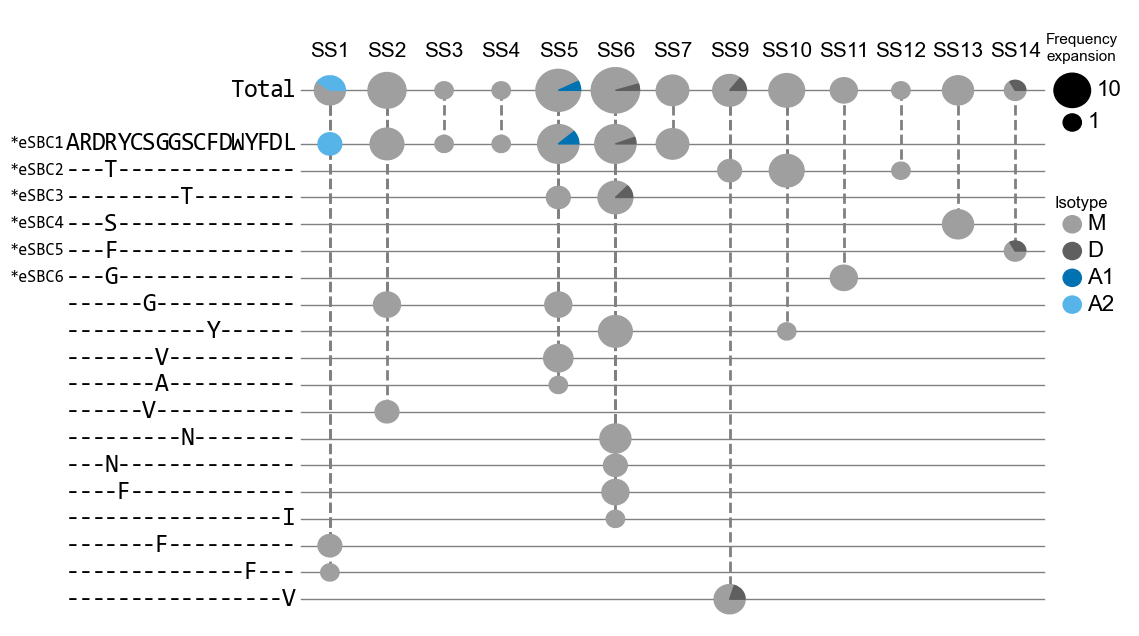

In [14]:
isotypes = ['IGHM', 'IGHD','IGHG3','IGHG1','IGHA1','IGHG2','IGHG4','IGHA2']
colors = ['#9F9F9F','#5F5F5F', '#F0E442', '#D55E00','#0072B2', '#E69F00', '#CC79A7', '#56B4E9']
new_list = tools.read_csv('sjogren/240923_new_analysis/extended_clonotype_sequence_list/IGHV4-59_IGHJ2_ARDRYCSGGSCFDWYFDL.csv')
print(new_list[0])
clonotype_dict = {}
patient_sequence_dict = {}
for line in new_list:
    clonotype = line[1]
    if clonotype not in clonotype_dict:
        clonotype_dict[clonotype] = {}
    patient = line[0]
    if patient not in clonotype_dict[clonotype]:
        clonotype_dict[clonotype][patient] = []
    clonotype_dict[clonotype][patient].append([float(line[2]),line[3],int(line[4]),line[5]])
    if patient not in patient_sequence_dict:
        patient_sequence_dict[patient] = []
    patient_sequence_dict[patient].append(line[5]+'_'+line[3])
    
contam_removed_clonotype_dict = {}
for clonotype in clonotype_dict:
    contam_removed_clonotype_dict[clonotype] = {}
    for patient in clonotype_dict[clonotype]:
        temp = clonotype_dict[clonotype][patient]
        unique_list = []
        for seq in temp:
            is_unique = True
            nt = seq[3]+'_'+seq[1]
            for query in patient_sequence_dict:
                if query != patient:
                    if nt in patient_sequence_dict[query]:
                        is_unique = False
            unique_list.append(is_unique)
        if True in unique_list:
            if patient not in contam_removed_clonotype_dict[clonotype]:
                contam_removed_clonotype_dict[clonotype][patient] = []
            contam_removed_clonotype_dict[clonotype][patient] = temp.copy()
        
for clonotype in contam_removed_clonotype_dict:
    print(clonotype)
    
plt.rcParams["figure.figsize"] = (14,8)
fig, ax = plt.subplots()

clonotype_list = [
'ARDRYCSGGSCFDWYFDL',
'ARDTYCSGGSCFDWYFDL',
'ARDRYCSGGTCFDWYFDL',
'ARDSYCSGGSCFDWYFDL',
'ARDFYCSGGSCFDWYFDL',
'ARDGYCSGGSCFDWYFDL',
'ARDRYCGGGSCFDWYFDL',
'ARDRYCSGGSCYDWYFDL',
'ARDRYCSVGSCFDWYFDL',
'ARDRYCSAGSCFDWYFDL',
'ARDRYCVGGSCFDWYFDL',
'ARDRYCSGGNCFDWYFDL',
'ARDNYCSGGSCFDWYFDL',
'ARDRFCSGGSCFDWYFDL',
'ARDRYCSGGSCFDWYFDI',
'ARDRYCSFGSCFDWYFDL',
'ARDRYCSGGSCFDWFFDL',
'ARDRYCSGGSCFDWYFDV'
]

median_freq_dict = {
'S10':1.0918508619070705e-06,
'S11':1.5542068493895852e-06,
'S12':1.1457811764193652e-06,
'S13':1.00290038792187e-06,
'S14':5.945815780789664e-06,
'S15':1.4570951060546673e-06,
'S16':1.8389350359419854e-06,
'S17':1.2727342149138996e-06,
'S18':1.3843838730353862e-06,
'S19':1.674607095310263e-06,
'S1':2.5162613389026585e-06,
'S20':3.6553314837356027e-06,
'S2':1.3645487505509365e-06,
'S3':1.5556284972473153e-06,
'S4':1.0573540560630267e-06,
'S5':1.2947279970687358e-06,
'S6':3.347000251025019e-06,
'S7':2.4956886977745943e-06,
'S8':1.5618654921438165e-05,
'S9':1.4420400829461456e-06,
}

y_scaling = 0.5
y_offset = 1-y_scaling
sorted_contam_removed_clonotype_dict = dict(sorted(contam_removed_clonotype_dict.items(), key=lambda item: len(item[1]), reverse=True))
yticks = ['Total']
xticks = ['S1','S2','S3','S4','S5','S6','S7','S9','S10','S11','S12','S13','S14']
total_isotype_freq = {}
for patient in xticks:
    total_isotype_freq[patient] = np.zeros(8)
    
for c,clonotype in enumerate(clonotype_list):
    temp = sorted_contam_removed_clonotype_dict[clonotype]
    yticks.append(clonotype)
    y_bias = y_offset

    for patient in temp:
        isotype_dict = {'IGHM':0,'IGHD':1,'IGHG3':2,'IGHG1':3,'IGHA1':4,'IGHG2':5,'IGHG4':6,'IGHA2':7}
        isotype_freq = np.zeros(8)
        seq_list = temp[patient]
        for seq in seq_list:
            isotype_freq[isotype_dict[seq[1]]] += seq[0]
            
        angle = 0
        #radius = 0.16*(7+np.log10(np.sum(isotype_freq)))
        radius = 0.16*(np.log10(np.sum(isotype_freq)/median_freq_dict[patient])+1)
        print(np.sum(isotype_freq)/median_freq_dict[patient])
        total_isotype_freq[patient] += isotype_freq
        for i in range(8):
            if isotype_freq[i] != 0:
                wedge = Wedge((xticks.index(patient),y_scaling*(c+1)+y_bias), radius, angle, angle+360*isotype_freq[i]/np.sum(isotype_freq),
                              color=colors[i], edgecolor=None)
                angle += 360*isotype_freq[i]/np.sum(isotype_freq)
                ax.add_patch(wedge)
                #circle = Circle((xticks.index(patient),y_scaling*(c+1)+y_bias),radius*1.15, color='k', fill=True,zorder=-5)
                #ax.add_patch(circle)
        plt.plot([xticks.index(patient),xticks.index(patient)],[0,y_scaling*(c+1)+y_bias],
                color='gray',linewidth=2,linestyle='--',zorder=-5)
             
for patient in total_isotype_freq:
    angle = 0
    #radius = 0.16*(7+np.log10(np.sum(total_isotype_freq[patient])))
    radius = 0.16*(np.log10(np.sum(total_isotype_freq[patient])/median_freq_dict[patient])+1)
    for i in range(8):
        if total_isotype_freq[patient][i] != 0:
            wedge = Wedge((xticks.index(patient),0), radius,
                          angle, angle+360*total_isotype_freq[patient][i]/np.sum(total_isotype_freq[patient]),
                          color=colors[i], edgecolor=None)
            angle += 360*total_isotype_freq[patient][i]/np.sum(total_isotype_freq[patient])
            ax.add_patch(wedge)
            #circle = Circle((xticks.index(patient),0),radius*1.15, color='k', fill=True,zorder=-5)
            #ax.add_patch(circle)
        
ax.set_axis_off()
ref_seq = 'ARDRYCSGGSCFDWYFDL'
plt.xlim(-5,len(xticks)+1)
circle = Circle((len(xticks), 0), 0.16*2, color='k', fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*2+0.1,0,'10',color='k',font='arial',fontsize=16,ha='left',va='center')
#plt.text(len(xticks)+0.16*2+0.5,-0.2,'-5',color='k',font='arial',fontsize=12,ha='left',va='center')
circle = Circle((len(xticks), 0.6), 0.16*1, color='k', fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*1+0.1,0.6,'1',color='k',font='arial',fontsize=16,ha='left',va='center')
#plt.text(len(xticks)+0.16*1+0.5,0.8,'-6',color='k',font='arial',fontsize=12,ha='left',va='center')
plt.text(len(xticks)+0.16, -0.5,'Frequency\nexpansion', color='k',font='arial',fontsize=11,ha='center',va='bottom')

circle = Circle((len(xticks), 2+1*y_scaling), 0.16*1, color=colors[0], fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*1+0.1,2+1*y_scaling,'M',color='k',font='arial',fontsize=16,ha='left',va='center')
circle = Circle((len(xticks), 2+2*y_scaling), 0.16*1, color=colors[1], fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*1+0.1,2+2*y_scaling,'D',color='k',font='arial',fontsize=16,ha='left',va='center')
circle = Circle((len(xticks), 2+3*y_scaling), 0.16*1, color=colors[4], fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*1+0.1,2+3*y_scaling,'A1',color='k',font='arial',fontsize=16,ha='left',va='center')
circle = Circle((len(xticks), 2+4*y_scaling), 0.16*1, color=colors[7], fill=True)
ax.add_patch(circle)
plt.text(len(xticks)+0.16*1+0.1,2+4*y_scaling,'A2',color='k',font='arial',fontsize=16,ha='left',va='center')
plt.text(len(xticks)+0.16, 2+0.5*y_scaling,'Isotype', color='k',font='arial',fontsize=12,ha='center',va='bottom')


plt.ylim(1+y_scaling*(len(yticks)-1),y_scaling*-3)
test_list = [
    'ARDRYCSGGSCFDWYFDL',
'ARDTYCSGGSCFDWYFDL',
'ARDRYCSGGTCFDWYFDL',
'ARDSYCSGGSCFDWYFDL',
'ARDFYCSGGSCFDWYFDL',
'ARDGYCSGGSCFDWYFDL',
]
for y,tick in enumerate(yticks):
    if y != 0:
        y_bias = y_offset
    else:
        y_bias = 0
    for c,char in enumerate(tick):
        if char != ref_seq[c] and y > 1:
            #plt.plot([-0.5-len(tick)/4.5+c*2/9-1/9,-0.5-len(tick)/4.5+c*2/9+1/9],
            #         [y_scaling*y+y_bias+y_scaling*0.23,y_scaling*y+y_bias+y_scaling*0.23],linewidth=2,color='r')
            plt.text(-0.5-len(tick)/4.5+c*2/9,y_scaling*y+y_bias,char,color='k',font='consolas',
                 fontsize=18,ha='center',va='center')
        elif y <= 1:
            plt.text(-0.5-len(tick)/4.5+c*2/9,y_scaling*y+y_bias,char,color='k',font='consolas',
                 fontsize=18,ha='center',va='center')
        else:
            plt.text(-0.5-len(tick)/4.5+c*2/9,y_scaling*y+y_bias,'-',color='k',font='consolas',
                 fontsize=18,ha='center',va='center')
            
    if tick in test_list:
        plt.text(-0.9-len(tick)/4.5-2/9,y_scaling*y+y_bias,'*eSBC'+str(int(test_list.index(tick)+1))+'',color='k',font='consolas',
                 fontsize=12,ha='center',va='center')
for x,tick in enumerate(xticks):
    plt.text(x,-0.55,'S'+tick,font='arial',fontsize=15,ha='center',va='bottom')
        
for i in range(len(yticks)):
    if i != 0:
        plt.plot([-0.5,len(xticks)-0.5],[y_scaling*i+y_offset,y_scaling*i+y_offset],color='gray',linewidth=1,linestyle='-',zorder=-5)
    else:
        plt.plot([-0.5,len(xticks)-0.5],[0,0],color='gray',linewidth=1,linestyle='-',zorder=-5)

#for i in range(len(xticks)):
#    plt.plot([i,i],[0,len(yticks)],color='gray',linewidth=1,linestyle='-',zorder=-5)
plt.savefig("sjogren/240923_new_analysis/eSBC1_patient_profile.tiff",dpi=300)
plt.show()

>S1-1
TVSGGSVSGYYWSWIRQPPGKGLEWIGYMYYSGSTNYNPSLKSRVTISVDTSKNQFSLKLTSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S2-1
TVSGGSISSYYWSWVRQPPGKGLEWIGYIYYSGSTNYNPSLKSRVTISVDTSENQFSLKLSSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S2-2
TVSGGSISSYYWSWIRQSPGKGLEWIGYIYYSGSTNYNPSPKSRVTISVDTSENQFSLKLSSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S3-1
TVSGGSISGYSWSWIRQAPGKGLEWIGYIYYSGSTNYNPSLKSRVTISVDTSNNQFSLKLSSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S4-1
TVSGGPISSYYWSWIRQSPGKGLEWIGFIHSSGRTNYNPSLKSRVAISVDTSKNRFSLKLSSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S5-1
TVSGASISGYSWSWIRQPPGKGLEWIGFVHDSGITNYNPSLKSRVTISVDTSENQFSLRLSSVTAADTAIYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S5-2
TVSGGSISGYYWSWIRQPPGKGLEWIGYIHDSGNTNYNPSLKSRVSISVDTSESQFSLKLSSVTAADTAIYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S5-3
TVSGGSISGYYWSWIRQPPGKGLEWIGYIHDSGSTNYNPSLKSRVTISVDTSESQFSLKLSSVTAADTAIYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S6-1
TVSGGPISSYYWSWIRQPPGKGLEWIGYIYYSGNTNYNPSLKSRVTISIDTSKNQFSLTLSSVTAADTAVYYCARDRYCSGGSCFDWYFDLWGRGTLVTVSS
>S6-2
TVSGGPISGHYWS

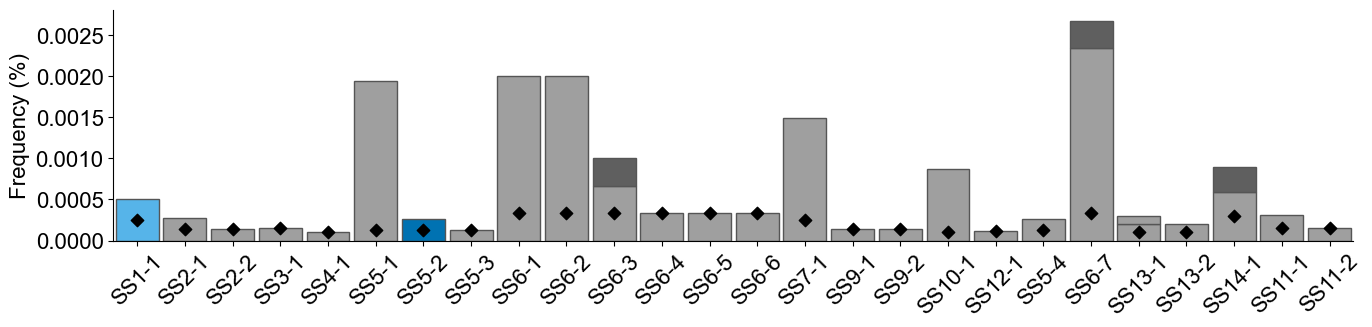

In [15]:
workdir = 'sjogren/240923_new_analysis/'
msa = 'msa_RF_all.aln'
new_list = tools.read_tsv(workdir+msa)
seq_dict = {}
for i in range(int(len(new_list)/2)):
    seq_dict[new_list[2*i][0].replace('>','')] = new_list[2*i+1][0]
J = seq_dict['IGHJ2*01'].replace('-','')
V = seq_dict['IGHV4-59*01'].replace('-','')

full_seq_dict = {}
for key in seq_dict:
    if key not in ['IGHJ2*01','IGHV4-59*01','CZ-01-0207 light chain','RF-MR20','CZ-01-0207','S8-1']:
    #if key not in ['IGHJ2*01','IGHV4-59*01','CZ-01-0207 light chain','S8-1']:
        seq = seq_dict[key]
        true_seq = ''
        for i in range(75):
            if seq[i] == '-':
                true_seq += V[i]
            else:
                true_seq += seq[i]
        for i in range(75,86):
            true_seq += seq[i]
        for i in range(86,102):
            if seq[i] == '-':
                true_seq += J[i-86]
            else:
                true_seq += seq[i]
        full_seq_dict[key] = [true_seq,[]]
        
for key in full_seq_dict:
    print('>'+key)
    print(full_seq_dict[key][0])
    patient = key.split('-')[0]
    if key not in ['IGHJ2*01','IGHV4-59*01','CZ-01-0207 light chain','RF-MR20','CZ-01-0207','S8-1']:
        new_list = tools.read_tsv('sjogren/new_sjogren_file/'+patient+'_add_d_gene.tsv')
        freq_index = new_list[0].index('frequency')
        c_index = new_list[0].index('c_call')
        aa_index = new_list[0].index('sequence_aa')
        for line in new_list:
            if line[aa_index] == full_seq_dict[key][0]:
                full_seq_dict[key][1].append([float(line[freq_index]),line[c_index].split('*')[0]])
                
print(full_seq_dict)
med_dict = {
'S1':2.5162613389026585e-06,
'S2':1.3645487505509365e-06,
'S3':1.5556284972473153e-06,
'S4':1.0573540560630267e-06,
'S5':1.2947279970687358e-06,
'S6':3.347000251025019e-06,
'S7':2.4956886977745943e-06,
'S8':7.809327460719083e-06,
'S9':1.4420400829461456e-06,
'S10':1.0918508619070705e-06,
'S11':1.5542068493895852e-06,
'S12':1.1457811764193652e-06,
'S13':1.00290038792187e-06,
'S14':2.972907890394832e-06,
'S15':1.4570951060546673e-06,
'S16':1.8389350359419854e-06,
'S17':1.2727342149138996e-06,
'S18':1.3843838730353862e-06,
'S19':1.674607095310263e-06,
'S20':3.6553314837356027e-06,
}
isotypes = ['IGHM', 'IGHD','IGHG3','IGHG1','IGHA1','IGHG2','IGHG4','IGHA2']
color_dict = {'IGHM':'#9F9F9F','IGHD':'#5F5F5F', 'IGHG3':'#F0E442', 'IGHG1':'#D55E00',
              'IGHA1':'#0072B2','IGHG2':'#E69F00','IGHG4':'#CC79A7','IGHA2':'#56B4E9'}
plt.rcParams["figure.figsize"] = (16,3)
fig, ax = plt.subplots()
xlabel = []
for k,key in enumerate(full_seq_dict):
    bottom = 0
    xlabel.append('S'+key)
    for seq in full_seq_dict[key][1]:
        plt.bar(k,seq[0]*100,width=0.9,edgecolor='#555555',linewidth=1,color=color_dict[seq[1]],bottom=bottom)
        bottom += seq[0]*100
        
plt.xticks(range(len(xlabel)),xlabel,font='arial',fontsize = 16,rotation=45)
plt.yticks(font='arial',fontsize = 16)
plt.ylabel('Frequency (%)',font='arial',fontsize = 16)
#plt.ylim(len(label_list)-0.5,-0.5)
plt.xlim(-0.5,len(xlabel)-0.5)
#plt.yscale('log')
#plt.ylim(0,0.003)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for i in range(len(xlabel)):
    plt.scatter(i,100*med_dict[xlabel[i][1:].split('-')[0]],s=40,marker='D',color='k',zorder=40)
plt.show()

3.0088920559440038e-05


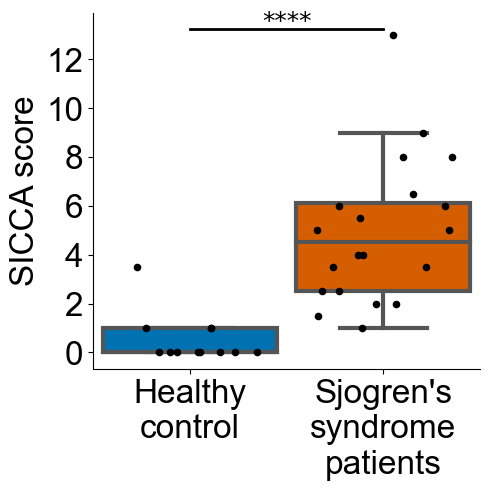

0.0030853001164447783


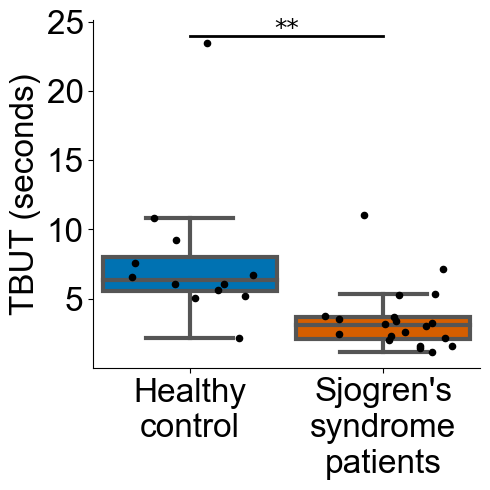

0.00048755362621558714


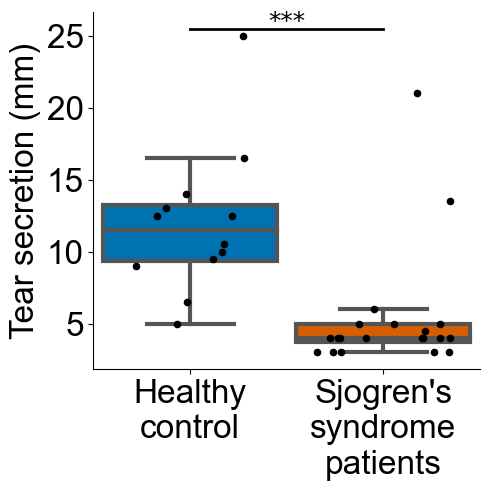

In [23]:
sjogren_sicca = [1,2.5,2,3.5,13,5,8,2,9,6,5,1.5,6.5,4,8,3.5,2.5,4,6,5.5]
healthy_sicca = [0,0,0,1,0,0,0,0,1,1,3.5,0]

width=0.9
linewidth=3
bias=0.22
plt.rcParams["figure.figsize"] = (5,5) 
fig,ax = plt.subplots(1,1)
for i in range(1):
    plt.boxplot([sjogren_sicca],sym='',positions = [1],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in sjogren_sicca:
        plt.scatter(1+0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
    plt.boxplot([healthy_sicca],sym='',positions = [0],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in healthy_sicca:
        plt.scatter(0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
        
    plot_significance(healthy_sicca,sjogren_sicca,0,1,
                      max(healthy_sicca+sjogren_sicca)*1.02,0,18,2)

plt.yticks(font='arial',fontsize = 24)
plt.xticks([0,1],['Healthy\ncontrol',"Sjogren's\nsyndrome\npatients"],font='arial',fontsize = 24)
plt.xlim(-0.5, 1.5)
#plt.ylim(0, 4)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('SICCA score',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
#plt.plot([-0.5, len(isotypes) + 0.5],[0,0],color='k',linewidth=2,zorder=-5)
plt.tight_layout()
#plt.savefig(work_dir+'figures/in-house_DB_divergence_box_and_violin.png')
plt.show()

sjogren_sicca = [3.71,5.35,2.265,5.275,1.55,2.415,2.135,3.365,3.655,1.425,2.585,11.05,3.265,3.495,7.14,3.16,3.04,1.155,1.54,1.97]
healthy_sicca = [10.845,23.5,6.08,6.675,7.555,5.035,5.64,9.23,6.555,6.035,2.175,5.175]

width=0.9
linewidth=3
bias=0.22

fig,ax = plt.subplots(1,1)
for i in range(1):
    plt.boxplot([sjogren_sicca],sym='',positions = [1],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in sjogren_sicca:
        plt.scatter(1+0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
    plt.boxplot([healthy_sicca],sym='',positions = [0],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in healthy_sicca:
        plt.scatter(0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
        
    plot_significance(healthy_sicca,sjogren_sicca,0,1,
                      max(healthy_sicca+sjogren_sicca)*1.02,0,18,2)

plt.yticks(font='arial',fontsize = 24)
plt.xticks([0,1],['Healthy\ncontrol',"Sjogren's\nsyndrome\npatients"],font='arial',fontsize = 24)
plt.xlim(-0.5, 1.5)
#plt.ylim(0, 4)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('TBUT (seconds)',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
#plt.plot([-0.5, len(isotypes) + 0.5],[0,0],color='k',linewidth=2,zorder=-5)
plt.tight_layout()
#plt.savefig(work_dir+'figures/in-house_DB_divergence_box_and_violin.png')
plt.show()

sjogren_sicca = [5,21,3,4.5,4,4,4,6,5,4,3,13.5,4,4,5,3,4,4,3,3]
healthy_sicca = [10.5,25,13,9,12.5,5,16.5,9.5,14,12.5,6.5,10]

width=0.9
linewidth=3
bias=0.22

fig,ax = plt.subplots(1,1)
for i in range(1):
    plt.boxplot([sjogren_sicca],sym='',positions = [1],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#D55E00','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in sjogren_sicca:
        plt.scatter(1+0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
    plt.boxplot([healthy_sicca],sym='',positions = [0],widths = [width],patch_artist=True,
                     boxprops = {'facecolor':'#0072B2','edgecolor':'#555555','linewidth':3},
                    whiskerprops = {'color':'#555555','linewidth':3},
                    capprops = {'color':'#555555','linewidth':3},
                    medianprops = {'color':'#555555','linewidth':3})
    for val in healthy_sicca:
        plt.scatter(0.8*width*(rd.random()-0.5),val,color='k',s=20,zorder=40)
        
    plot_significance(healthy_sicca,sjogren_sicca,0,1,
                      max(healthy_sicca+sjogren_sicca)*1.02,0,18,2)

plt.yticks(font='arial',fontsize = 24)
plt.xticks([0,1],['Healthy\ncontrol',"Sjogren's\nsyndrome\npatients"],font='arial',fontsize = 24)
plt.xlim(-0.5, 1.5)
#plt.ylim(0, 4)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Tear secretion (mm)',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.xlabel('Isotype',font='arial',fontsize = 24)
#plt.title('Mutation count',font='serif',fontsize = 48,fontweight='bold')
#plt.plot([-0.5, len(isotypes) + 0.5],[0,0],color='k',linewidth=2,zorder=-5)
plt.tight_layout()
#plt.savefig(work_dir+'figures/in-house_DB_divergence_box_and_violin.png')
plt.show()

In [3]:
seq_file = 'sjogren/240923_new_analysis/RF_sequence_mismatch_4_mapping_result.csv'
#seq_file = 'sjogren/240923_new_analysis/RF_sequence_mismatch_18_mapping_result.csv'
new_list = tools.read_csv(seq_file)

ref_clonotype = 'IGHV4-59_IGHJ2_ARDRYCSGGSCFDWYFDL'
ref_cdr3 = ref_clonotype.split('_')[2]
cdr3_dict = {}
for line in new_list[1:]:
    group = line[1].split('/')[1]
    file = line[2].replace('.tsv','').replace('_e1_a1_f1_c1','').replace('_add_d_gene','')
    cdr3 = line[5]
    nt = line[10]
    c = line[7]
    if cdr3 not in cdr3_dict:
        cdr3_dict[cdr3] = []
    cdr3_dict[cdr3].append('|'.join([group,file,nt+'_'+c]))
    
sharing_cdr3_dict = {}
for cdr3 in cdr3_dict:
    temp_dict = {}
    for seq in cdr3_dict[cdr3]:
        if seq.split('|')[2] not in temp_dict:
            temp_dict[seq.split('|')[2]] = []
        temp_dict[seq.split('|')[2]].append('|'.join(seq.split('|')[:2]))
    has_unique = []
    for seq in temp_dict:
        temp = []
        for file in temp_dict[seq]:
            if file not in temp:
                temp.append(file)
        if len(temp) == 1:
            if temp[0] not in has_unique:
                has_unique.append(temp[0])
    ss_count = 0
    ra_count = 0
    idd_count = 0
    healthy_count = 0
    for file in has_unique:
        if file.split('|')[0] == 'SS':
            ss_count += 1
        if file.split('|')[0] == 'RA':
            ra_count += 1
        if file.split('|')[0] == 'NMO' and 'CIDP' not in file:
            idd_count += 1
        if file.split('|')[0] == 'SARSCoV2WT_vaccination' or file.split('|')[0] == 'MG_control':
            healthy_count += 1
    sharing_cdr3_dict[cdr3] = [ss_count,ra_count,idd_count,healthy_count]+has_unique

sorted_sharing_cdr3_dict = dict(sorted(sharing_cdr3_dict.items(), key=lambda item: item[1][0],reverse=True))
for cdr3 in sorted_sharing_cdr3_dict:
    print(cdr3, sorted_sharing_cdr3_dict[cdr3])


ARDRYCSGGSCFDWYFDL [7, 3, 1, 0, 'RA|RA13_RF+', 'RA|RA4_RF-', 'RA|RA10_RF+', 'Hecto_control|2-9', 'COVID19_infection|N', 'MG|MP153_t1_B', 'MG|AP135_t1_B', 'MG|AP121_t3_B', 'NMO|CIDP_1', 'NMO|DSN_4', 'AD|SNUBH-20-1', 'AD|SNUBH-38-1', 'AD|SNUBH-20-2', 'XBB_vaccination|XBB_2_17', 'XBB_vaccination|XBB_1_17', 'SS|S5', 'SS|S2', 'SS|S6', 'SS|S4', 'SS|S7', 'SS|S1', 'SS|S3']
ARDTYCSGGSCFDWYFDL [3, 1, 1, 0, 'RA|RA10_RF+', 'NMO|NMO_4', 'AD|SNUBH-20-1', 'AD|SNUBH-20-2', 'SS|S12', 'SS|S10', 'SS|S9']
ARDRYCSGGTCFDWYFDL [2, 1, 0, 0, 'RA|RA10_RF+', 'NMO|CIDP_3', 'AD|SNUBH-12-1', 'AD|SNUBH-12-2', 'AD|SNUBH-20-2', 'SS|S5', 'SS|S6']
ARDRYCSGGSCYDWYFDL [2, 0, 0, 0, 'Hecto_control|3-9', 'Hecto_control|7-9', 'Hecto_control|2-9', 'NMO|CIDP_1', 'SS|S6', 'SS|S10']
ARDRYCGGGSCFDWYFDL [2, 0, 0, 0, 'AD|SNUBH-20-1', 'AD|SNUBH-20-2', 'SS|S5', 'SS|S2']
ARDGYCRGGSCFDWYFDL [2, 0, 0, 0, 'SS|S5', 'SS|S11']
ARDSYCSGGSCFDWYFDL [1, 1, 0, 0, 'RA|RA13_RF+', 'AD_Mook|AD02', 'AD|SNUBH-20-1', 'SS|S13']
ARDRYCSGGSCFDWYFDI [1, 1, 

ARDRYCSGGSCFDWYFDL 0 7 3 1 0 O
ARDTYCSGGSCFDWYFDL 1 3 1 1 0 O
ARDRYCSGGTCFDWYFDL 1 2 1 0 0 O
ARDRYCSGGSCYDWYFDL 1 2 0 0 0 O
ARDRYCGGGSCFDWYFDL 1 2 0 0 0 X
ARDGYCRGGSCFDWYFDL 2 2 0 0 0 X
ARDSYCSGGSCFDWYFDL 1 1 1 0 0 O
ARDRYCSGGSCFDWYFDI 1 1 1 0 0 X
ARDAYCRGGSCFDWYFDL 2 1 0 0 0 X
ARDRYCSGGSCFDWYFDV 1 1 0 1 0 O
ARDGYCSGGSCFDWYFDL 1 1 0 0 0 X
ARDSYCGGGTCFDWYFDL 3 1 0 0 0 X
ARDRFCSGGSCFDWYFDL 1 1 0 0 0 O
ARDRYCSGGSCFDWFFDL 1 1 0 0 0 X
ARDRYCSAGSCFDWYFDL 1 1 0 0 0 X
ARDRYCGAGSCFDWYFDL 2 1 0 0 0 X
ARDRYCSVGSCFDWYFDL 1 1 0 0 0 X
ARDRYCSGGNCYDWFFDL 3 1 0 0 0 X
ARQGYCSGGSCSWWYFDL 4 1 0 0 0 X
ARDGYCRGGSCFDYYFDL 3 1 0 0 0 X
ARDGYCRGGSCFDWFFDL 3 1 0 0 0 X
ARDRYCRAGNCFDWYFDV 4 1 0 0 0 X
ARDRYCDAGTCYDWYFDL 4 1 0 0 0 X
ARDRYCGGGTCFDWYLDL 3 1 0 0 0 X
ARDVYCRGGTCFDWYFDL 3 1 0 0 0 X
ARDGYCRGGSCFDWYSDL 3 1 0 0 0 X
ARDRFCSGGSCYDWYFDL 2 1 0 0 0 X
ARDQYCSAGNCFDWYFDF 4 1 0 0 0 X
ARDRYCTVGTCFDWYFDL 3 1 0 0 0 X
ARDQYCRSGSCFDWYFDL 3 1 0 0 0 X
ARDEYCRGGSCFDWYFDL 2 1 0 0 0 X
ARDRYCTGGTCYDWYFDL 3 1 0 0 0 X
ARDRYCSG

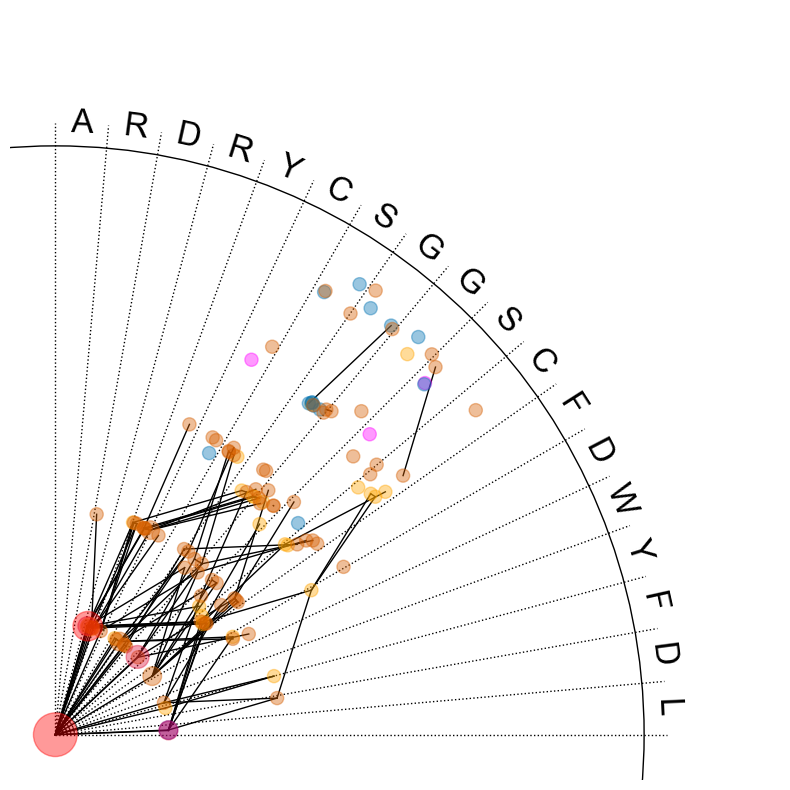

In [6]:
color_dict = {'M': '#00FF00', 'D': '#98FB98', 'G3': '#0000CD',
              'G1': '#0000FF', 'A1': '#B22222', 'G2': '#6495ED',
              'G4': '#87CEEB', 'E': '#FF69B4', 'A2': '#FF0000'}
color_list = ['#D55E00','orange','turquoise','#0072B2',
              'crimson','limegreen','purple','green','gray']
color_list = ['#D55E00','orange','magenta','#0072B2',
              'crimson','limegreen','purple','red','gray']

cll_dict = {
    'ARDRYCSGGSCFDWYFDL',
    'ARDRYCSGGTCFDWYFDL',
    'ARDQYCSGGTCFDWYFDL',
    'ARDQYCKGGSCFDWFFDL',
    'ARDAYCSGGTCFDWYFDV',
    'ARDRYCSGGSCFDWYFDV',
    'ARDSYCSGGSCFDWFFDL',
    'ARDRYCSGGSCYDWYFDL',
    'ARDGYCSGGTCFDWYFDL',
    'ARDRYCSGGSCFDWYFDF',
    'ARDAYCSGGSCFDWYFDL',
    'ARDTYCSGGSCFDWYFDL',
    'ARDRFCSGGSCFDWYFDL',
    'ARDSYCSGGSCFDWYFDL'
}

limited_dict = {}
for cdr3 in sorted_sharing_cdr3_dict:
    if sum(sorted_sharing_cdr3_dict[cdr3][:4]) > 0:
    #if sorted_sharing_cdr3_dict[cdr3][0] > 0 or sorted_sharing_cdr3_dict[cdr3][1] > 0 or sorted_sharing_cdr3_dict[cdr3][2] > 0 or sorted_sharing_cdr3_dict[cdr3][3] > 0:
    #if sorted_sharing_cdr3_dict[cdr3][3] > 0:
    #if sorted_sharing_cdr3_dict[cdr3][2] > 0:
    #if sorted_sharing_cdr3_dict[cdr3][1] > 0:
    #if sorted_sharing_cdr3_dict[cdr3][0] > 0:
        limited_dict[cdr3] = sorted_sharing_cdr3_dict[cdr3][:4]
        if cdr3 in cll_dict:
            cll_status = 'O'
        else:
            cll_status = 'X'
        if hamming_dist(ref_cdr3,cdr3) <= 4:
            print(cdr3, hamming_dist(ref_cdr3,cdr3), ' '.join([str(x) for x in sorted_sharing_cdr3_dict[cdr3][:4]]), cll_status)
        
plt.rcParams["figure.figsize"] = (8,8)
aa_list = ['R','H','K','D','E','S','T','N','Q','A','V','I','L','M','F','Y','W','P','G','C']
mut_angle_dict = {}
length = len(ref_cdr3)
start = 0
total = length*20
for i in range(length):
    for aa in aa_list:
        mut_angle_dict[str(i)+aa] = 0.5*np.pi-(start+0.5)*0.5*np.pi/total
        start += 1
            
cdr3_list = [x for x in limited_dict]

total_cdr3_pair = 0
convergence_event = 0
only_cdr3_list = [x.split(':')[0] for x in cdr3_list]
cdr3_dict = {}
for cdr3 in cdr3_list:
    cdr3_dict[cdr3] = None
for c,cdr3 in enumerate(cdr3_list):
    if hamming_dist(ref_cdr3,cdr3) == 15:
        print(ref_cdr3)
        print(cdr3)
    for query in cdr3_list[:c]:
        if hamming_dist(query,cdr3) == 2:
            total_cdr3_pair += 1
            intermediate_list = intermediate_seq(cdr3,query)
            has_intermediate_list = []
            for intermediate in intermediate_list:
                if intermediate in cdr3_dict:
                    has_intermediate_list.append(True)
                else:
                    has_intermediate_list.append(False)
            if False not in has_intermediate_list:
                convergence_event += 1

ref_cdr3 = 'ARDRYCSGGSCFDWYFDL'
#ref_cdr3 = 'VRLYKAPIIRPLHHFFDV'
root_cdr3 = ref_cdr3

print(root_cdr3)
cdr3_dict = {}

for cdr3 in limited_dict:
    temp = limited_dict[cdr3]
    if temp[0] > 0 and temp[1] == 0 and temp[2] == 0 and temp[3] == 0:
        color = color_list[0]
    elif temp[0] == 0 and temp[1] > 0 and temp[2] == 0 and temp[3] == 0:
        color = color_list[1]
    elif temp[0] == 0 and temp[1] == 0 and temp[2] > 0 and temp[3] == 0:
        color = color_list[2]
    elif temp[0] == 0 and temp[1] == 0 and temp[2] == 0 and temp[3] > 0:
        color = color_list[3]
    elif temp[0] > 0 and temp[1] > 0 and temp[2] == 0 and temp[3] == 0:
        color = color_list[4]
    elif temp[0] == 0 and temp[1] > 0 and temp[2] > 0 and temp[3] == 0:
        color = color_list[5]
    elif temp[0] > 0 and temp[1] == 0 and temp[2] > 0 and temp[3] == 0:
        color = color_list[6]
    elif temp[0] > 0 and temp[1] > 0 and temp[2] > 0 and temp[3] == 0:
        color = color_list[7]
    else:
        color = color_list[8]
        
    #cdr3_dict[cdr3] = [temp[0],10+30*(sum(temp)-1),color]
    cdr3_dict[cdr3] = [temp[0],90+90*(sum(temp)-1),color]

cdr3_dict = dict(sorted(cdr3_dict.items(), key=lambda x:x[1][0]))
#print(cdr3_dict)
fig,ax = plt.subplots(1,1)

x_val = []
y_val = []
color_val = []
s_val = []
cdr3_list = []
for q,query in enumerate(cdr3_dict):
    temp = cdr3_dict[query]
    init = np.zeros(2)
    s_val.append(temp[1])
    color_val.append(temp[2])

    for i in range(len(root_cdr3)):
        if query[i] != root_cdr3[i]:
            angle = mut_angle_dict[str(i)+query[i]]
            #angle = mut_angle_dict[query[i]+root_cdr3[i]]
            vec = np.array([np.cos(angle),np.sin(angle)])
            init += vec
    x_val.append(init[0])
    y_val.append(init[1])
    cdr3_list.append(query)

edge_list_1 = []
for q,query in enumerate(cdr3_dict):
    for s,subject in enumerate(cdr3_dict):
        if q > s and hamming_dist(query,subject) <= 1:
            edge_list_1.append([[x_val[q],x_val[s]],[y_val[q],y_val[s]]])

"""           
for i in range(len(cdr3_list)):
    if cdr3_list[i] in cll_dict:
        marker = '*'
    else:
        marker = 'o'
    plt.scatter(x_val[i],y_val[i],s=s_val[i],color=color_val[i],zorder=5,marker=marker,alpha=0.4)
""" 
plt.scatter(x_val,y_val,s=s_val,color=color_val,zorder=5,alpha=0.4)
linewidth=1
for edge in edge_list_1:
    plt.plot(edge[0],edge[1],color = 'k',linewidth=linewidth,zorder=-5)

#max_val = max(max(np.abs(np.array(x_val))),max(np.abs(np.array(y_val))))
max_val = 4
#max_val = 11
edge = plt.Circle((0, 0), max_val*1.3, color='k',linewidth=1, fill=False,zorder=0)
ax.add_patch(edge)
for i in range(length+1):
    radius = max_val*1.35
    #angle = i*0.5*np.pi/length
    angle = 0.5*np.pi-i*0.5*np.pi/length
    plt.plot([0,radius*np.cos(angle)],[0,radius*np.sin(angle)],
            color='k',linewidth=1, linestyle = ':', zorder=0)

for i in range(length):
    #text_angle = (i+0.5)*0.5*np.pi/length
    text_angle = 0.5*np.pi-(i+0.5)*0.5*np.pi/length
    plt.text(radius*np.cos(text_angle),radius*np.sin(text_angle),root_cdr3[i],
            ha='center',va='center',rotation = -90+180*text_angle/np.pi,color='k',
            font='arial',fontsize = 24)


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])
plt.xticks(font='arial',fontsize = 16)
#plt.xlabel('Average SHM',font='arial',fontsize = 20)
plt.yticks(font='arial',fontsize = 16)
plt.xlim(-4*0.1,max_val*1.6)
plt.ylim(-4*0.1,max_val*1.6)
#plt.xlim(1,11)
#plt.ylim(1,11)
#plt.title(cluster[0].replace('_',' ')+'('+cluster[2]+') '+"%.1f" % (100*convergence_event/(total_cdr3_pair))+'%',font='arial',fontsize = 20)
plt.tight_layout()
plt.show()

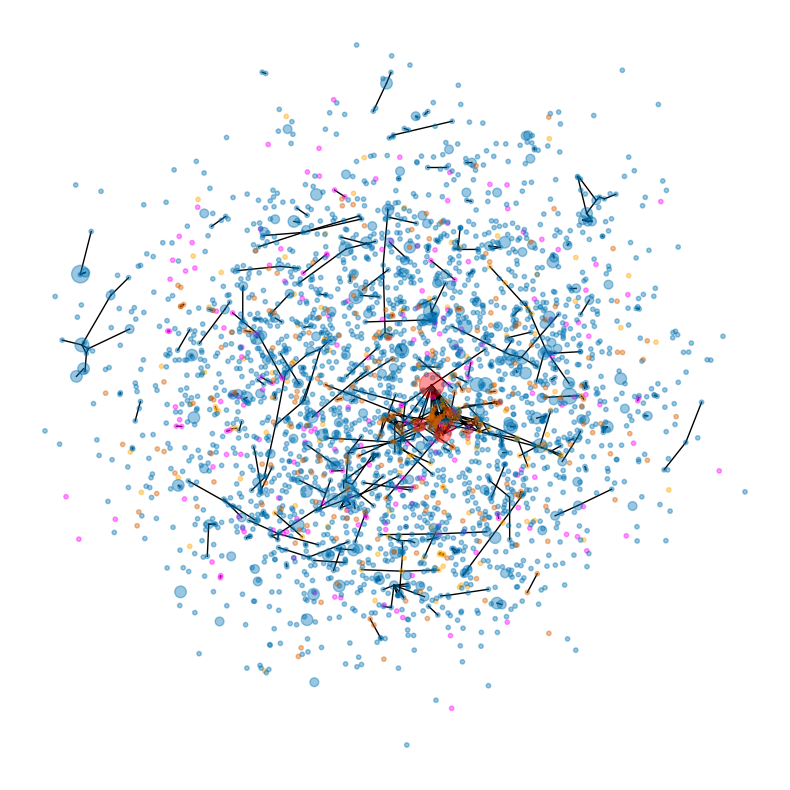

In [7]:
plt.rcParams["figure.figsize"] = (8,8)

color_list = ['#D55E00','orange','turquoise','#0072B2',
              'crimson','limegreen','purple','green','gray']
color_dict = {'#D55E00':'#D55E00','orange':'orange','turquoise':'magenta','#0072B2':'#0072B2',
              'crimson':'crimson','limegreen':'limegreen','purple':'purple','green':'red','gray':'gray'}
#for i in range(1,33):
for i in range(10,11):
    fig,ax = plt.subplots(1,1)
    new_list = tools.read_csv('sjogren/240923_new_analysis/RF_clustering_gif_source/RF_clonotype_group_iteration_'+str(i)+'_coords.csv')
    #new_list = tools.read_csv('sjogren/240923_new_analysis/RF_clonotype_group_init_coords.csv')

    new_cdr3_dict = {}
    new_x_val = []
    new_y_val = []
    new_s_val = []
    new_color_val = []
    for line in new_list[1:]:
        if True:
        #if line[4] != '#0072B2' and line[4] != 'gray' :
        #if line[4] == 'gray' :
        #if line[4] == '#0072B2' or line[4] == 'gray' :
            new_cdr3_dict[line[0]] = None
            new_x_val.append(float(line[1]))
            new_y_val.append(float(line[2]))
            new_s_val.append(float(line[3]))
            new_color_val.append(color_dict[line[4]])

    new_edge_list_1 = []
    for q,query in enumerate(new_cdr3_dict):
        for s,subject in enumerate(new_cdr3_dict):
            if hamming_dist(query,subject) <= 1:
                if q > s:
                    new_edge_list_1.append([[new_x_val[q],new_x_val[s]],[new_y_val[q],new_y_val[s]]])

    plt.scatter(new_x_val,new_y_val,s=new_s_val,color=new_color_val,zorder=5,alpha=0.4)
    linewidth=1
    for edge in new_edge_list_1:
        plt.plot(edge[0],edge[1],color = 'k',linewidth=linewidth,zorder=-5)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    plt.xticks(font='arial',fontsize = 16)
    #plt.xlabel('Average SHM',font='arial',fontsize = 20)
    plt.yticks(font='arial',fontsize = 16)
    #plt.xlim(-8,8)
    #plt.ylim(-8,8)
    #plt.title(cluster[0].replace('_',' ')+'('+cluster[2]+') '+"%.1f" % (100*convergence_event/(total_cdr3_pair))+'%',font='arial',fontsize = 20)
    plt.tight_layout()
    plt.show()